# Libraries

In [18]:
import os
import sys
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import f1_score

sys.path.append("PyTorch_CIFAR10")
from cifar10_models.resnet import resnet18
from thop import profile

In [15]:
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")


device = get_device()
print("Device:", device)

Device: mps


In [9]:
def check_gpu_memory():

    if device.type == "mps":
        current = torch.mps.current_allocated_memory() / (1024 ** 2)
        driver = torch.mps.driver_allocated_memory() / (1024 ** 2)

        print(f"Current GPU memory: {current:.2f} MB")
        print(f"Driver GPU memory: {driver:.2f} MB")

    elif device.type == "cuda":
        current = torch.cuda.memory_allocated() / (1024 ** 2)

        print(f"Current GPU memory: {current:.2f} MB")

    else:
        print("GPU memory measurement is not available on CPU.")
check_gpu_memory()

Current GPU memory: 0.00 MB
Driver GPU memory: 0.38 MB


### Hyper Parameters

In [16]:
BATCH_SIZE = 256

# Task 0: Load and Profile the Base Model


### Download the required model repository

In [3]:
!git clone https://github.com/huyvnphan/PyTorch_CIFAR10.git

Cloning into 'PyTorch_CIFAR10'...
remote: Enumerating objects: 690, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 690 (delta 52), reused 36 (delta 36), pack-reused 624 (from 1)
Receiving objects: 100% (690/690), 6.58 MiB | 4.50 MiB/s, done.
Resolving deltas: 100% (269/269), done.


## Helper Functions

In [6]:
# Load Model
def load_model():
    model = resnet18()
    weights_path = "state_dicts/resnet18.pt"
    checkpoint = torch.load(
        weights_path,
        map_location="cpu"
    )
    model.load_state_dict(checkpoint)
    model = model.to(device)
    model.eval()
    return model
# Load Data
def load_data(batch_size=256):
    mean = (0.4914, 0.4822, 0.4465)
    std = (0.2471, 0.2435, 0.2616)
    # Training preprocessing
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    # Evaluation preprocessing
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    train_dataset = datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=train_transform
    )
    test_dataset = datasets.CIFAR10(
        root="./data",
        train=False,
        download=True,
        transform=test_transform
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, test_loader
# Evaluate Model
def evaluate_model(model, loader, run_device=None):
    run_device = run_device or device

    all_predictions = []
    all_labels = []
    correct_top1 = 0
    correct_top5 = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(run_device)
            labels = labels.to(run_device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)
            correct_top1 += (predictions == labels).sum().item()

            top5 = outputs.topk(5, dim=1).indices
            correct_top5 += (top5 == labels.unsqueeze(1)).any(dim=1).sum().item()

            total += labels.size(0)
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    top1 = 100 * correct_top1 / total
    top5 = 100 * correct_top5 / total
    macro_f1 = f1_score(all_labels, all_predictions, average="macro")

    return top1, top5, macro_f1
# Count Parameters
def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
    )
# Get Model Size
def get_model_size(model):

    path = "temp_model.pt"

    torch.save(model.state_dict(), path)

    size_mb = os.path.getsize(path) / (1024 ** 2)

    os.remove(path)

    return size_mb
# Get MACs and FLOPs
def get_macs_flops(model):

    dummy_input = torch.randn(
        1, 3, 32, 32
    ).to(device)

    macs, _ = profile(
        model,
        inputs=(dummy_input,),
        verbose=False
    )

    flops = 2 * macs

    return macs, flops
# Measure Latency
def measure_latency(model, loader, warmup=10, batches=50, run_device=None):
    run_device = run_device or device

    images, _ = next(iter(loader))
    images = images.to(run_device)

    with torch.no_grad():
        for _ in range(warmup):
            model(images)
    synchronize(run_device)

    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(batches):
            model(images)
    synchronize(run_device)

    elapsed = time.perf_counter() - start
    return (elapsed / batches) * 1000

def get_gpu_memory_mb(run_device=None):
    run_device = run_device or device

    if run_device.type == "mps":
        return torch.mps.current_allocated_memory() / (1024 ** 2)
    elif run_device.type == "cuda":
        return torch.cuda.memory_allocated() / (1024 ** 2)
    return 0.0
def profile_gpu_memory(model, loader, batches=50, run_device=None):
    run_device = run_device or device

    images, _ = next(iter(loader))
    images = images.to(run_device)

    with torch.no_grad():
        for _ in range(10):
            model(images)
    synchronize(run_device)

    memory_usage = []
    with torch.no_grad():
        for _ in range(batches):
            model(images)
            synchronize(run_device)
            memory_usage.append(get_gpu_memory_mb(run_device))

    average_memory = sum(memory_usage) / len(memory_usage)
    peak_memory = max(memory_usage)
    return average_memory, peak_memory
def synchronize(run_device):
    if run_device.type == "mps":
        torch.mps.synchronize()
    elif run_device.type == "cuda":
        torch.cuda.synchronize()
def compute_loss(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            total_loss += criterion(model(inputs), targets).item() * inputs.size(0)
            total += targets.size(0)

    return total_loss / total


## Task 0 main Calling Functions

In [19]:
# Load the model
model = load_model()
# Load the data
train_loader, test_loader = load_data(
    batch_size=BATCH_SIZE
)

In [18]:
# Main Execution

# Load the model
model = load_model()
# Load the data
train_loader, test_loader = load_data(
    batch_size=BATCH_SIZE
)
# Evaluate the model
train_top1, train_top5, train_f1 = evaluate_model(
    model,
    train_loader
)
test_top1, test_top5, test_f1 = evaluate_model(
    model,
    test_loader
)
# Model Statistics
parameters = count_parameters(model)
model_size = get_model_size(model)
macs, flops = get_macs_flops(model)
# Measure Latency
latency = measure_latency(
    model,
    test_loader,
    warmup=10,
    batches=50
)
# GPU Memory
average_gpu_memory, peak_gpu_memory = profile_gpu_memory(
    model,
    test_loader,
    batches=50
)


100.0%


## Task 0 Results

In [19]:
print("\n---------------Load the model-------------\n")
print("Model loaded successfully.")
print("---------------Load the model-------------\n")
print("Training samples:", len(train_loader.dataset))
print("Testing samples:", len(test_loader.dataset))
print("Batch size:", BATCH_SIZE)
print("---------------Evaluate the model-------------\n")
print("Train Top-1:", train_top1)
print("Test Top-1:", test_top1)
print("Test Top-5:", test_top5)
print("Test Macro-F1:", test_f1)
print("\n---------------Model Statistics-------------\n")
print(f"Parameters: {parameters:,}")
print(f"Parameters: {parameters / 1e6:.3f} M")
print(f"Model size: {model_size:.2f} MB")
print(f"MACs: {macs / 1e6:.2f} M")
print(f"FLOPs: {flops / 1e6:.2f} M")
print("\n---------------Latency Measurement-------------\n")
print(f"Average inference latency: {latency:.2f} ms")
print(f"Average GPU Memory: {average_gpu_memory:.2f} MB")
print(f"Peak GPU Memory: {peak_gpu_memory:.2f} MB")




---------------Load the model-------------

Model loaded successfully.
---------------Load the model-------------

Training samples: 50000
Testing samples: 10000
Batch size: 256
---------------Evaluate the model-------------

Train Top-1: 99.76
Test Top-1: 93.07
Test Top-5: 99.74
Test Macro-F1: 0.9307003258502717

---------------Model Statistics-------------

Parameters: 11,173,962
Parameters: 11.174 M
Model size: 42.70 MB
MACs: 141.00 M
FLOPs: 282.00 M

---------------Latency Measurement-------------

Average inference latency: 67.79 ms
Average GPU Memory: 46.17 MB
Peak GPU Memory: 46.17 MB


## Model and Data Configuration

| Setting | Value |
|---|---|
| Model | Pretrained ResNet-18 |
| Dataset | CIFAR-10 |
| Batch size | 256 |
| Input resolution | 32 × 32 |
| Normalization mean | (0.4914, 0.4822, 0.4465) |
| Normalization std | (0.2471, 0.2435, 0.2616) |
| Training augmentation | Random Crop (32, padding=4) + Random Horizontal Flip |
| Test augmentation | None |
| Device | Apple MPS |



### Energy Consumption

CPU and GPU energy consumption could not be measured directly through the PyTorch MPS backend used in this experiment. PyTorch provides MPS GPU and memory APIs, but energy measurement is handled through separate macOS performance tools such as Instruments and `powermetrics`. Therefore, CPU and GPU energy values are reported as **Not Available** for this experiment.

**References:**
- [PyTorch MPS Backend Documentation](https://docs.pytorch.org/docs/stable/notes/mps.html)
- [PyTorch MPS GPU Memory Documentation](https://docs.pytorch.org/docs/main/generated/torch.mps.driver_allocated_memory.html)
- [Apple: Energy Efficiency Guide for Mac Apps](https://developer.apple.com/library/archive/documentation/Performance/Conceptual/power_efficiency_guidelines_osx/MonitoringEnergyUsage.html)
- [Apple: Porting macOS Apps to Apple Silicon](https://developer.apple.com/documentation/Apple-Silicon/porting-your-macos-apps-to-apple-silicon)

*Note: this latency was measured in an earlier session. All later comparisons use the baseline latency re-measured in Task 1 Part 7 (34.94 ms), where every model was profiled in the same run.*

# Task 1: Unstructured Post-Training Pruning

### Task 1 — Part 1: Layer-wise Sensitivity Analysis

In [13]:
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import pandas as pd
import torch.nn.functional as F

### Helper functions 

In [ ]:
# Pruning Utilities
def get_prunable_layers(model):
    layers = []

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            layers.append(name)

    return layers
# Prune One Layer
def prune_one_layer(model, layer_name, sparsity):
    for name, module in model.named_modules():
        if name == layer_name:
            prune.l1_unstructured(
                module,
                name="weight",
                amount=sparsity
            )
            prune.remove(module, "weight")
            break

    return model
# Sensitivity Analysis
def sensitivity_analysis(model, test_loader):
    sparsity_levels = [0, 0.10, 0.20, 0.50, 0.70, 0.80, 0.90]

    layers = get_prunable_layers(model)
    results = {}

    print(f"Total prunable layers: {len(layers)}")
    print(f"Sparsity levels: {[int(s * 100) for s in sparsity_levels]}")
    print("-" * 60)

    for layer_index, layer_name in enumerate(layers, start=1):
        layer_results = []

        print(f"\nLayer {layer_index}/{len(layers)}: {layer_name}")

        for sparsity in sparsity_levels:

            print(f"  Testing sparsity: {sparsity * 100:.0f}%", end=" ... ")

            # Start from the original dense model
            test_model = copy.deepcopy(model)
            test_model = test_model.to(device)
            test_model.eval()

            # Prune only the selected layer
            if sparsity > 0:
                prune_one_layer(
                    test_model,
                    layer_name,
                    sparsity
                )

            # Evaluate
            top1, top5, macro_f1 = evaluate_model(
                test_model,
                test_loader
            )

            layer_results.append({
                "sparsity": sparsity,
                "top1": top1,
                "top5": top5,
                "macro_f1": macro_f1
            })

            print(f"Top-1: {top1:.2f}%")

            del test_model

        results[layer_name] = layer_results

        print(f"  Completed: {layer_name}")

    print("\n" + "-" * 60)
    print("Sensitivity analysis completed.")

    return results

### main calling function 

In [19]:
model = load_model()
sensitivity_results = sensitivity_analysis(
    model,
    test_loader
)

Total prunable layers: 21
Sparsity levels: [0, 10, 20, 50, 70, 80, 90]
------------------------------------------------------------

Layer 1/21: conv1
  Testing sparsity: 0% ... Top-1: 93.07%
  Testing sparsity: 10% ... Top-1: 93.07%
  Testing sparsity: 20% ... Top-1: 93.04%
  Testing sparsity: 50% ... Top-1: 92.06%
  Testing sparsity: 70% ... Top-1: 79.21%
  Testing sparsity: 80% ... Top-1: 42.24%
  Testing sparsity: 90% ... Top-1: 22.15%
  Completed: conv1

Layer 2/21: layer1.0.conv1
  Testing sparsity: 0% ... Top-1: 93.07%
  Testing sparsity: 10% ... Top-1: 93.07%
  Testing sparsity: 20% ... Top-1: 93.08%
  Testing sparsity: 50% ... Top-1: 92.93%
  Testing sparsity: 70% ... Top-1: 92.64%
  Testing sparsity: 80% ... Top-1: 91.69%
  Testing sparsity: 90% ... Top-1: 88.68%
  Completed: layer1.0.conv1

Layer 3/21: layer1.0.conv2
  Testing sparsity: 0% ... Top-1: 93.07%
  Testing sparsity: 10% ... Top-1: 93.05%
  Testing sparsity: 20% ... Top-1: 93.09%
  Testing sparsity: 50% ... Top-1: 

### Results 


Layer: conv1
Sparsity: 0% | Top-1: 93.07% | Top-5: 99.74% | F1: 0.9307
Sparsity: 10% | Top-1: 93.07% | Top-5: 99.74% | F1: 0.9307
Sparsity: 20% | Top-1: 93.04% | Top-5: 99.74% | F1: 0.9304
Sparsity: 50% | Top-1: 92.06% | Top-5: 99.68% | F1: 0.9204
Sparsity: 70% | Top-1: 79.21% | Top-5: 97.53% | F1: 0.7866
Sparsity: 80% | Top-1: 42.24% | Top-5: 83.88% | F1: 0.3999
Sparsity: 90% | Top-1: 22.15% | Top-5: 65.93% | F1: 0.1794

Layer: layer1.0.conv1
Sparsity: 0% | Top-1: 93.07% | Top-5: 99.74% | F1: 0.9307
Sparsity: 10% | Top-1: 93.07% | Top-5: 99.74% | F1: 0.9307
Sparsity: 20% | Top-1: 93.08% | Top-5: 99.74% | F1: 0.9308
Sparsity: 50% | Top-1: 92.93% | Top-5: 99.77% | F1: 0.9293
Sparsity: 70% | Top-1: 92.64% | Top-5: 99.76% | F1: 0.9264
Sparsity: 80% | Top-1: 91.69% | Top-5: 99.70% | F1: 0.9170
Sparsity: 90% | Top-1: 88.68% | Top-5: 99.33% | F1: 0.8869

Layer: layer1.0.conv2
Sparsity: 0% | Top-1: 93.07% | Top-5: 99.74% | F1: 0.9307
Sparsity: 10% | Top-1: 93.05% | Top-5: 99.74% | F1: 0.9305

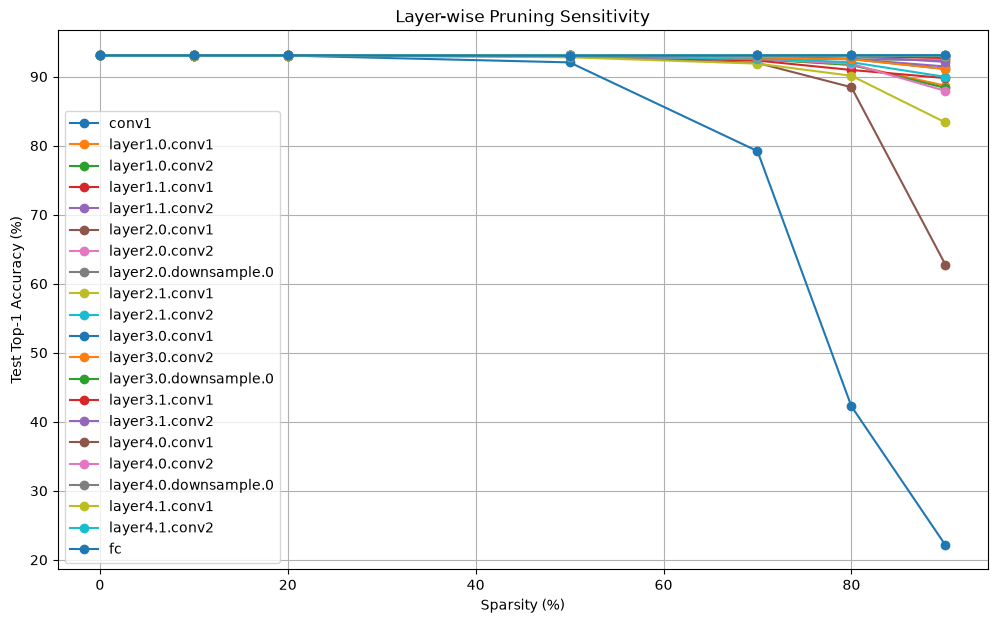

In [20]:
for layer_name, results in sensitivity_results.items():
    print("\nLayer:", layer_name)

    for result in results:
        print(
            f"Sparsity: {result['sparsity'] * 100:.0f}% | "
            f"Top-1: {result['top1']:.2f}% | "
            f"Top-5: {result['top5']:.2f}% | "
            f"F1: {result['macro_f1']:.4f}"
        )
def plot_sensitivity(results):
    plt.figure(figsize=(12, 7))

    for layer_name, layer_results in results.items():
        sparsities = [
            result["sparsity"] * 100
            for result in layer_results
        ]

        accuracies = [
            result["top1"]
            for result in layer_results
        ]

        plt.plot(
            sparsities,
            accuracies,
            marker="o",
            label=layer_name
        )

    plt.xlabel("Sparsity (%)")
    plt.ylabel("Test Top-1 Accuracy (%)")
    plt.title("Layer-wise Pruning Sensitivity")
    plt.legend()
    plt.grid(True)
    plt.show()
plot_sensitivity(sensitivity_results)

### Task 1 — Part 2: Local Magnitude Pruning.

In [20]:
# first experiment with local pruning
# local_sparsity = {
#     "conv1": 0.50,

#     "layer1.0.conv1": 0.80,
#     "layer1.0.conv2": 0.80,
#     "layer1.1.conv1": 0.80,
#     "layer1.1.conv2": 0.90,

#     "layer2.0.conv1": 0.50,
#     "layer2.0.conv2": 0.80,
#     "layer2.0.downsample.0": 0.90,
#     "layer2.1.conv1": 0.70,
#     "layer2.1.conv2": 0.90,

#     "layer3.0.conv1": 0.90,
#     "layer3.0.conv2": 0.90,
#     "layer3.0.downsample.0": 0.90,
#     "layer3.1.conv1": 0.90,
#     "layer3.1.conv2": 0.90,

#     "layer4.0.conv1": 0.90,
#     "layer4.0.conv2": 0.90,
#     "layer4.0.downsample.0": 0.90,
#     "layer4.1.conv1": 0.90,
#     "layer4.1.conv2": 0.90,

#     "fc": 0.90
# }
# second experiment with local pruning
local_sparsity = {
    "conv1": 0.30,

    "layer1.0.conv1": 0.60,
    "layer1.0.conv2": 0.60,
    "layer1.1.conv1": 0.60,
    "layer1.1.conv2": 0.70,

    "layer2.0.conv1": 0.30,
    "layer2.0.conv2": 0.60,
    "layer2.0.downsample.0": 0.80,
    "layer2.1.conv1": 0.50,
    "layer2.1.conv2": 0.70,

    "layer3.0.conv1": 0.80,
    "layer3.0.conv2": 0.80,
    "layer3.0.downsample.0": 0.80,
    "layer3.1.conv1": 0.80,
    "layer3.1.conv2": 0.80,

    "layer4.0.conv1": 0.80,
    "layer4.0.conv2": 0.80,
    "layer4.0.downsample.0": 0.80,
    "layer4.1.conv1": 0.80,
    "layer4.1.conv2": 0.80,

    "fc": 0.80
}
model = load_model()

### helper functions

In [108]:
# Apply Local Pruning
def apply_local_pruning(model, sparsity_dict):

    for name, module in model.named_modules():

        if name in sparsity_dict:
            sparsity = sparsity_dict[name]

            prune.l1_unstructured(
                module,
                name="weight",
                amount=sparsity
            )

            prune.remove(module, "weight")

    return model
# Calculate Layer Sparsity
def calculate_layer_sparsity(model):

    results = {}

    for name, module in model.named_modules():

        if isinstance(module, (nn.Conv2d, nn.Linear)):

            weights = module.weight.data

            total = weights.numel()
            zeros = torch.sum(weights == 0).item()

            sparsity = zeros / total

            results[name] = {
                "total_weights": total,
                "zero_weights": zeros,
                "sparsity": sparsity
            }

    return results
# Calculate Overall Sparsity
def calculate_overall_sparsity(model):

    total_weights = 0
    zero_weights = 0

    for module in model.modules():

        if isinstance(module, (nn.Conv2d, nn.Linear)):

            weights = module.weight.data

            total_weights += weights.numel()
            zero_weights += torch.sum(weights == 0).item()

    overall_sparsity = zero_weights / total_weights

    return overall_sparsity, total_weights, zero_weights

### part 2 main 

In [22]:
local_model = copy.deepcopy(model)
local_model = local_model.to(device)

local_model = apply_local_pruning(
    local_model,
    local_sparsity
)
layer_results = calculate_layer_sparsity(local_model)
overall_sparsity, total_weights, zero_weights = \
    calculate_overall_sparsity(local_model)
train_top1, train_top5, train_f1 = evaluate_model(
    local_model,
    train_loader
)
test_top1, test_top5, test_f1 = evaluate_model(
    local_model,
    test_loader
)



### results

In [23]:
# Overall Sparsity
print("Layer-wise sparsity")
print("-" * 60)

for name, result in layer_results.items():

    print(
        f"{name:30s} | "
        f"Sparsity: {result['sparsity'] * 100:.2f}%"
    )


print("\nOverall Sparsity")
print("-" * 60)

print(f"Total prunable weights: {total_weights:,}")
print(f"Zero weights:           {zero_weights:,}")
print(f"Non-zero weights:       {total_weights - zero_weights:,}")
print(f"Overall sparsity:       {overall_sparsity * 100:.2f}%")

print("\nLocal Pruning Evaluation")

print("-" * 60)
print(f"Train Top-1: {train_top1:.2f}%")
print(f"Train Top-5: {train_top5:.2f}%")
print(f"Train Macro-F1: {train_f1:.4f}")
print(f"Test Top-1: {test_top1:.2f}%")
print(f"Test Top-5: {test_top5:.2f}%")
print(f"Test Macro-F1: {test_f1:.4f}")

Layer-wise sparsity
------------------------------------------------------------
conv1                          | Sparsity: 29.98%
layer1.0.conv1                 | Sparsity: 60.00%
layer1.0.conv2                 | Sparsity: 60.00%
layer1.1.conv1                 | Sparsity: 60.00%
layer1.1.conv2                 | Sparsity: 70.00%
layer2.0.conv1                 | Sparsity: 30.00%
layer2.0.conv2                 | Sparsity: 60.00%
layer2.0.downsample.0          | Sparsity: 80.00%
layer2.1.conv1                 | Sparsity: 50.00%
layer2.1.conv2                 | Sparsity: 70.00%
layer3.0.conv1                 | Sparsity: 80.00%
layer3.0.conv2                 | Sparsity: 80.00%
layer3.0.downsample.0          | Sparsity: 80.00%
layer3.1.conv1                 | Sparsity: 80.00%
layer3.1.conv2                 | Sparsity: 80.00%
layer4.0.conv1                 | Sparsity: 80.00%
layer4.0.conv2                 | Sparsity: 80.00%
layer4.0.downsample.0          | Sparsity: 80.00%
layer4.1.conv1     

### Task 1 — Part 3: Global Magnitude Pruning

### helper functions

In [24]:
# Global Pruning Functions

def apply_global_pruning(model, target_sparsity):
    parameters_to_prune = []

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            parameters_to_prune.append((module, "weight"))

    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=target_sparsity
    )

    return model


def calculate_global_sparsity(model):
    total_weights = 0
    zero_weights = 0

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            mask = module.weight_mask

            total_weights += mask.numel()
            zero_weights += mask.numel() - mask.sum().item()

    sparsity = zero_weights / total_weights
    nonzero_weights = total_weights - zero_weights

    return sparsity, total_weights, int(zero_weights), int(nonzero_weights)


def calculate_global_layer_sparsity(model):
    results = {}

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            mask = module.weight_mask

            total = mask.numel()
            remaining = mask.sum().item()
            zeros = total - remaining

            results[name] = {
                "total": total,
                "zeros": int(zeros),
                "sparsity": zeros / total
            }

    return results


def check_fully_pruned_layers(model):
    fully_pruned = []

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            if module.weight_mask.sum().item() == 0:
                fully_pruned.append(name)

    return fully_pruned

### Main / Calling Functions

In [25]:
# Main: Apply Global Pruning

target_sparsity = 0.7864

global_model = copy.deepcopy(model)
global_model = global_model.to(device)

global_model = apply_global_pruning(
    global_model,
    target_sparsity
)

global_layer_results = calculate_global_layer_sparsity(global_model)

global_sparsity, total_weights, zero_weights, nonzero_weights = (
    calculate_global_sparsity(global_model)
)

fully_pruned_layers = check_fully_pruned_layers(global_model)

global_model.eval()

train_top1, train_top5, train_f1 = evaluate_model(
    global_model,
    train_loader
)

test_top1, test_top5, test_f1 = evaluate_model(
    global_model,
    test_loader
)

### Print Results

In [26]:
# Global Pruning Results

print("=" * 60)
print("GLOBAL MAGNITUDE PRUNING RESULTS")
print("=" * 60)

print("\nOverall Sparsity")
print("-" * 60)
print(f"Target sparsity    : {target_sparsity * 100:.2f}%")
print(f"Actual sparsity    : {global_sparsity * 100:.2f}%")
print(f"Total weights      : {total_weights:,}")
print(f"Zero weights       : {zero_weights:,}")
print(f"Non-zero weights   : {nonzero_weights:,}")

print("\nLayer-wise Sparsity")
print("-" * 60)

for name, result in global_layer_results.items():
    print(
        f"{name:25s} "
        f"{result['sparsity'] * 100:6.2f}%"
    )

print("\nFully Pruned Layers")
print("-" * 60)

if len(fully_pruned_layers) == 0:
    print("No layer is completely pruned.")
else:
    for name in fully_pruned_layers:
        print(name)

print("\nAccuracy Before Fine-tuning")
print("-" * 60)

print(f"Train Top-1 : {train_top1:.2f}%")
print(f"Train Top-5 : {train_top5:.2f}%")
print(f"Train F1    : {train_f1:.4f}")

print(f"Test Top-1  : {test_top1:.2f}%")
print(f"Test Top-5  : {test_top5:.2f}%")
print(f"Test F1     : {test_f1:.4f}")

GLOBAL MAGNITUDE PRUNING RESULTS

Overall Sparsity
------------------------------------------------------------
Target sparsity    : 78.64%
Actual sparsity    : 78.64%
Total weights      : 11,164,352
Zero weights       : 8,779,646
Non-zero weights   : 2,384,706

Layer-wise Sparsity
------------------------------------------------------------
conv1                      16.72%
layer1.0.conv1             25.98%
layer1.0.conv2              9.86%
layer1.1.conv1             10.78%
layer1.1.conv2             12.45%
layer2.0.conv1             10.53%
layer2.0.conv2             11.31%
layer2.0.downsample.0       7.18%
layer2.1.conv1             12.51%
layer2.1.conv2             16.03%
layer3.0.conv1             18.63%
layer3.0.conv2             28.78%
layer3.0.downsample.0      19.42%
layer3.1.conv1             45.47%
layer3.1.conv2             63.05%
layer4.0.conv1             87.93%
layer4.0.conv2             92.13%
layer4.0.downsample.0      28.82%
layer4.1.conv1             99.21%
layer4.1.c

### Comparison: Dense vs Local vs Global Pruning (Before Fine-tuning)

| Model | Overall Sparsity | Train Top-1 | Test Top-1 | Test Top-5 | Macro-F1 |
|---|---:|---:|---:|---:|---:|
| Dense Baseline | 0.00% | 99.76% | 93.07% | 99.74% | 0.9307 |
| Local Pruning | 78.64% | 95.02% | 88.85% | 99.24% | 0.8889 |
| Global Pruning | 78.64% | 99.74% | 93.11% | 99.75% | 0.9312 |

### Layer-wise Sparsity: Local vs Global

| Layer | Local | Global |
|---|---:|---:|
| conv1 | 29.98% | 16.72% |
| layer1.0.conv1 | 60.00% | 25.98% |
| layer1.0.conv2 | 60.00% | 9.86% |
| layer1.1.conv1 | 60.00% | 10.78% |
| layer1.1.conv2 | 70.00% | 12.45% |
| layer2.0.conv1 | 30.00% | 10.53% |
| layer2.0.conv2 | 60.00% | 11.31% |
| layer2.0.downsample.0 | 80.00% | 7.18% |
| layer2.1.conv1 | 50.00% | 12.51% |
| layer2.1.conv2 | 70.00% | 16.03% |
| layer3.0.conv1 | 80.00% | 18.63% |
| layer3.0.conv2 | 80.00% | 28.78% |
| layer3.0.downsample.0 | 80.00% | 19.42% |
| layer3.1.conv1 | 80.00% | 45.47% |
| layer3.1.conv2 | 80.00% | 63.05% |
| layer4.0.conv1 | 80.00% | 87.93% |
| layer4.0.conv2 | 80.00% | 92.13% |
| layer4.0.downsample.0 | 80.00% | 28.82% |
| layer4.1.conv1 | 80.00% | 99.21% |
| layer4.1.conv2 | 80.00% | 94.52% |
| fc | 80.00% | 0.12% |
| **Overall** | **78.64%** | **78.64%** |

### Observation

Both methods use the same sparsity of **78.64%**, but global pruning keeps much higher accuracy (**93.11%** vs **88.85%**).

Global pruning removes more weights from the large late layers (`layer4`: 88–99%) and fewer from the sensitive early layers (`conv1`: 16.72%). Local pruning used fixed manual ratios that pruned the early layers too much. No layer was fully pruned.

### Task 1 — Part 4: Fine-tuning with Fixed Masks

### Helper Functions

In [27]:
# Fine-tuning Functions

def create_fixed_masks(model):
    masks = {}

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            masks[name] = (module.weight.data != 0).float()

    return masks


def apply_masks(model, masks=None):
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):

            # Global model: use pruning mask
            if hasattr(module, "weight_mask"):
                module.weight.data.mul_(module.weight_mask)

            # Local model: use saved fixed mask
            elif masks is not None:
                module.weight.data.mul_(masks[name])


def fine_tune_model(
    model,
    train_loader,
    test_loader,
    epochs,
    learning_rate,
    device,
    masks=None
):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate,
        momentum=0.9,
        weight_decay=5e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    history = {
        "train_loss": [],
        "train_top1": [],
        "test_top1": [],
         "test_loss": [],
    }

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, targets in train_loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            # Keep pruned weights at zero
            apply_masks(model, masks)

            running_loss += loss.item() * inputs.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == targets).sum().item()
            total += targets.size(0)

        scheduler.step()

        train_loss = running_loss / total
        train_top1 = 100.0 * correct / total

        model.eval()

        test_top1, _, _ = evaluate_model(
            model,
            test_loader
        )
        test_loss = compute_loss(model, test_loader, criterion)
        history["test_loss"].append(test_loss)


        history["train_loss"].append(train_loss)
        history["train_top1"].append(train_top1)
        history["test_top1"].append(test_top1)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Loss: {train_loss:.4f} | "
            f"Train Top-1: {train_top1:.2f}% | "
            f"Test Top-1: {test_top1:.2f}%",
             f"Val Loss: {test_loss:.4f} | "
        )

    return model, history

### Main / Calling Functions

In [28]:
# Fine-tuning Settings

EPOCHS = 10
LEARNING_RATE = 0.01
SEED = 42


# --------------------------------------------------
# Fine-tune Local Model with Fixed Mask
# --------------------------------------------------

torch.manual_seed(SEED)

local_model_fixed = copy.deepcopy(local_model).to(device)

local_masks = create_fixed_masks(local_model_fixed)

local_ft_model, local_history = fine_tune_model(
    local_model_fixed,
    train_loader,
    test_loader,
    EPOCHS,
    LEARNING_RATE,
    device,
    masks=local_masks
)


# --------------------------------------------------
# Fine-tune Global Model with Fixed Mask
# --------------------------------------------------

torch.manual_seed(SEED)

global_ft_model = copy.deepcopy(global_model).to(device)

global_ft_model, global_history = fine_tune_model(
    global_ft_model,
    train_loader,
    test_loader,
    EPOCHS,
    LEARNING_RATE,
    device
)

Epoch 1/10 | Loss: 0.5457 | Train Top-1: 82.04% | Test Top-1: 75.51% Val Loss: 0.7866 | 
Epoch 2/10 | Loss: 0.3523 | Train Top-1: 88.15% | Test Top-1: 83.48% Val Loss: 0.5258 | 
Epoch 3/10 | Loss: 0.2777 | Train Top-1: 90.57% | Test Top-1: 87.11% Val Loss: 0.3972 | 
Epoch 4/10 | Loss: 0.2200 | Train Top-1: 92.34% | Test Top-1: 89.20% Val Loss: 0.3407 | 
Epoch 5/10 | Loss: 0.1775 | Train Top-1: 93.94% | Test Top-1: 89.65% Val Loss: 0.3385 | 
Epoch 6/10 | Loss: 0.1349 | Train Top-1: 95.46% | Test Top-1: 90.35% Val Loss: 0.3174 | 
Epoch 7/10 | Loss: 0.1041 | Train Top-1: 96.51% | Test Top-1: 91.47% Val Loss: 0.2905 | 
Epoch 8/10 | Loss: 0.0803 | Train Top-1: 97.35% | Test Top-1: 92.33% Val Loss: 0.2690 | 
Epoch 9/10 | Loss: 0.0595 | Train Top-1: 98.11% | Test Top-1: 92.50% Val Loss: 0.2631 | 
Epoch 10/10 | Loss: 0.0497 | Train Top-1: 98.46% | Test Top-1: 92.70% Val Loss: 0.2581 | 
Epoch 1/10 | Loss: 0.7586 | Train Top-1: 74.50% | Test Top-1: 75.07% Val Loss: 0.7657 | 
Epoch 2/10 | Loss: 0

### Results

In [29]:
# Fine-tuning Results

local_ft_top1, local_ft_top5, local_ft_f1 = evaluate_model(
    local_ft_model,
    test_loader
)

global_ft_top1, global_ft_top5, global_ft_f1 = evaluate_model(
    global_ft_model,
    test_loader
)

print("=" * 60)
print("FINE-TUNING RESULTS")
print("=" * 60)

print("\nLocal Pruning + Fine-tuning")
print("-" * 60)
print(f"Test Top-1  : {local_ft_top1:.2f}%")
print(f"Test Top-5  : {local_ft_top5:.2f}%")
print(f"Test Macro-F1: {local_ft_f1:.4f}")

print("\nGlobal Pruning + Fine-tuning")
print("-" * 60)
print(f"Test Top-1  : {global_ft_top1:.2f}%")
print(f"Test Top-5  : {global_ft_top5:.2f}%")
print(f"Test Macro-F1: {global_ft_f1:.4f}")

FINE-TUNING RESULTS

Local Pruning + Fine-tuning
------------------------------------------------------------
Test Top-1  : 92.70%
Test Top-5  : 99.75%
Test Macro-F1: 0.9270

Global Pruning + Fine-tuning
------------------------------------------------------------
Test Top-1  : 92.07%
Test Top-5  : 99.73%
Test Macro-F1: 0.9207


### Comparison: Before vs After Fine-tuning

| Model | Before FT Top-1 | After FT Top-1 | Improvement |
|---|---:|---:|---:|
| Local Pruning | 88.85% | 92.70% | +3.85 pp |
| Global Pruning | 93.11% | 92.07% | -1.04 pp |

### Final Fine-tuning Results

| Model | Test Top-1 | Test Top-5 | Test Macro-F1 |
|---|---:|---:|---:|
| Dense Baseline | 93.07% | 99.74% | 0.9307 |
| Local Pruning + Fine-tuning | 92.70% | 99.75% | 0.9270 |
| Global Pruning + Fine-tuning | 92.07% | 99.73% | 0.9207 |

### Observation

Fine-tuning improved the local-pruned model from **88.85% to 92.70%**, recovering **3.85 pp**.

The global-pruned model dropped from **93.11% to 92.07%** (**-1.04 pp**). It was already at baseline accuracy, so a learning rate of 0.01 slightly disturbed it.

Both final models stay within about **1 pp** of the dense baseline (**93.07%**).

### Task 1 — Part 5: Verify Pruning Masks

### helping functions 

In [ ]:
def verify_masks(pruned_model, finetuned_model):
    rows = []
    pruned_modules = dict(pruned_model.named_modules())

    for name, module in finetuned_model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):

            # Global model keeps weight_mask; local mask = zeros before fine-tuning
            if hasattr(module, "weight_mask"):
                mask = module.weight_mask
            else:
                mask = (pruned_modules[name].weight.data != 0).float()

            weight = module.weight.data
            pruned_positions = weight[mask == 0]

            rows.append({
                "Layer": name,
                "Mask Sparsity (%)": 100 * (1 - mask.mean().item()),
                "Weight Sparsity (%)": 100 * (weight == 0).float().mean().item(),
                "Non-zero in Pruned Positions": torch.count_nonzero(pruned_positions).item()
            })

    return pd.DataFrame(rows)

### Main / Calling

In [31]:
local_verification = verify_masks(local_model, local_ft_model)
global_verification = verify_masks(global_model, global_ft_model)

### Results

In [32]:
for title, table in [("Local Pruning", local_verification),
                     ("Global Pruning", global_verification)]:
    print("=" * 60)
    print(f"MASK VERIFICATION — {title}")
    print("=" * 60)
    display(table.round(2))

    if table["Non-zero in Pruned Positions"].sum() == 0:
        print("PASS: All pruned weights remained zero after fine-tuning.\n")
    else:
        print("FAIL: Some pruned weights became non-zero.\n")

MASK VERIFICATION — Local Pruning


,Layer,Mask Sparsity (%),Weight Sparsity (%),Non-zero in Pruned Positions
0,conv1,29.98,29.98,0
1,layer1.0.conv1,60.00,60.00,0
2,layer1.0.conv2,60.00,60.00,0
3,layer1.1.conv1,60.00,60.00,0
4,layer1.1.conv2,70.00,70.00,0
5,layer2.0.conv1,30.00,30.00,0
6,layer2.0.conv2,60.00,60.00,0
7,layer2.0.downsample.0,80.00,80.00,0
8,layer2.1.conv1,50.00,50.00,0
9,layer2.1.conv2,70.00,70.00,0


PASS: All pruned weights remained zero after fine-tuning.

MASK VERIFICATION — Global Pruning


,Layer,Mask Sparsity (%),Weight Sparsity (%),Non-zero in Pruned Positions
0,conv1,16.72,16.72,0
1,layer1.0.conv1,25.98,25.98,0
2,layer1.0.conv2,9.86,9.86,0
3,layer1.1.conv1,10.78,10.78,0
4,layer1.1.conv2,12.45,12.45,0
5,layer2.0.conv1,10.53,10.53,0
6,layer2.0.conv2,11.31,11.31,0
7,layer2.0.downsample.0,7.18,7.18,0
8,layer2.1.conv1,12.51,12.51,0
9,layer2.1.conv2,16.03,16.03,0


PASS: All pruned weights remained zero after fine-tuning.



### Observation

For every layer of both models, the sparsity calculated from the mask equals the sparsity measured directly from the weight tensor, and **0 non-zero values** exist in pruned positions after fine-tuning. The masks stayed fixed throughout training.

 ### Part 6: COO Sparse Storage

### helper functions 

In [46]:
def convert_to_coo(model):
    sparse_data = {}

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):

            weight = module.weight.data.cpu()

            # Default PyTorch COO format (int64 index per dimension)
            coo_weight = weight.to_sparse_coo()

            # Compact format: one flattened int32 index per non-zero weight
            flat_indices = torch.nonzero(weight.flatten()).squeeze(1).to(torch.int32)

            # Pruning mask stored as bool (1 byte per weight)
            if hasattr(module, "weight_mask"):
                mask = module.weight_mask.cpu().bool()
            else:
                mask = weight != 0

            sparse_data[name] = {
                "values": coo_weight.values(),
                "indices": coo_weight.indices(),
                "flat_indices": flat_indices,
                "shape": tuple(weight.shape),
                "mask": mask
            }

    return sparse_data


def calculate_coo_size(sparse_data):
    total_bytes = 0

    for layer in sparse_data.values():
        values = layer["values"]
        indices = layer["indices"]

        total_bytes += values.numel() * values.element_size()
        total_bytes += indices.numel() * indices.element_size()

    return total_bytes


def calculate_compact_coo_size(sparse_data):
    total_bytes = 0

    for layer in sparse_data.values():
        values = layer["values"]
        flat_indices = layer["flat_indices"]

        total_bytes += values.numel() * values.element_size()
        total_bytes += flat_indices.numel() * flat_indices.element_size()

    return total_bytes


def restore_from_compact(layer):
    numel = torch.Size(layer["shape"]).numel()
    weight = torch.zeros(numel)
    weight[layer["flat_indices"].long()] = layer["values"]
    return weight.view(layer["shape"])


def verify_compact_coo(model, sparse_data):
    for name, module in model.named_modules():
        if name in sparse_data:
            restored = restore_from_compact(sparse_data[name])
            if not torch.equal(restored, module.weight.data.cpu()):
                return False
    return True


def calculate_dense_size(model):
    total_bytes = 0

    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            total_bytes += module.weight.numel() * module.weight.element_size()

    return total_bytes


def save_coo(sparse_data, path):
    torch.save(sparse_data, path)
    return os.path.getsize(path)


def bytes_to_mb(size_bytes):
    return size_bytes / (1024 ** 2)


def storage_reduction(dense_size, sparse_size):
    return (1 - sparse_size / dense_size) * 100

## Calling the functions

In [47]:
# Convert both models to COO format
local_coo = convert_to_coo(local_ft_model)
global_coo = convert_to_coo(global_ft_model)

# Dense size
local_dense_size = calculate_dense_size(local_ft_model)
global_dense_size = calculate_dense_size(global_ft_model)

# Default COO size
local_coo_size = calculate_coo_size(local_coo)
global_coo_size = calculate_coo_size(global_coo)

# Compact COO size
local_compact_size = calculate_compact_coo_size(local_coo)
global_compact_size = calculate_compact_coo_size(global_coo)

# Check compact format is lossless
local_compact_ok = verify_compact_coo(local_ft_model, local_coo)
global_compact_ok = verify_compact_coo(global_ft_model, global_coo)

# Save values, indices, shapes and masks
local_coo_file_size = save_coo(local_coo, "local_pruned_coo.pt")
global_coo_file_size = save_coo(global_coo, "global_pruned_coo.pt")

### Results

In [48]:
print("=" * 60)
print("COO SPARSE STORAGE")
print("=" * 60)

for title, dense, coo, compact, ok, file_size in [
    ("Local Pruning", local_dense_size, local_coo_size,
     local_compact_size, local_compact_ok, local_coo_file_size),
    ("Global Pruning", global_dense_size, global_coo_size,
     global_compact_size, global_compact_ok, global_coo_file_size),
]:
    print(f"\n{title}")
    print("-" * 60)
    print(f"Dense weight size        : {bytes_to_mb(dense):.2f} MB")
    print(f"Default COO size         : {bytes_to_mb(coo):.2f} MB "
          f"| Reduction: {storage_reduction(dense, coo):.2f}%")
    print(f"Compact COO size (int32) : {bytes_to_mb(compact):.2f} MB "
          f"| Reduction: {storage_reduction(dense, compact):.2f}%")
    print(f"Compact COO lossless     : {'PASS' if ok else 'FAIL'}")
    print(f"Saved file (all data)    : {bytes_to_mb(file_size):.2f} MB")

COO SPARSE STORAGE

Local Pruning
------------------------------------------------------------
Dense weight size        : 42.59 MB
Default COO size         : 81.86 MB | Reduction: -92.22%
Compact COO size (int32) : 18.20 MB | Reduction: 57.28%
Compact COO lossless     : PASS
Saved file (all data)    : 101.63 MB

Global Pruning
------------------------------------------------------------
Dense weight size        : 42.59 MB
Default COO size         : 81.79 MB | Reduction: -92.06%
Compact COO size (int32) : 18.19 MB | Reduction: 57.28%
Compact COO lossless     : PASS
Saved file (all data)    : 101.56 MB


### COO Storage Results

| Model | Dense Size | Default COO | Reduction | Compact COO (int32) | Reduction | Lossless |
|---|---:|---:|---:|---:|---:|:---:|
| Local Pruning | 42.59 MB | 81.86 MB | -92.22% | 18.20 MB | 57.28% | PASS |
| Global Pruning | 42.59 MB | 81.79 MB | -92.06% | 18.19 MB | 57.28% | PASS |

### Observation

Default COO **increased** the size by about 92%. Each non-zero conv weight stores a float32 value (4 bytes) plus 4 int64 indices (32 bytes), which is **36 bytes** compared with **4 bytes** in dense format. With ~21% of weights remaining, this is larger than dense storage.

Storing one flattened int32 index per non-zero weight (8 bytes total) reduced storage to **18.2 MB**, a **57.28% reduction**, while restoring all weights exactly.

The saved files (~101.6 MB) contain values, both index formats, shapes and pruning masks for verification, so they are larger than the compact storage size.

## Part 7 — Sparse Inference and Profiling

### Helper Functions

In [49]:
def make_dense_masked(model):
    """Copy of the model with pruning re-parameterization removed (zeros stay zero)."""
    dense_model = copy.deepcopy(model)
    for module in dense_model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)) and hasattr(module, "weight_mask"):
            prune.remove(module, "weight")
    return dense_model.eval()


class SparseCOOConv2d(nn.Module):
    """Conv weight stored in COO format.
    PyTorch has no sparse convolution kernel, so the COO weight is
    converted back to dense before every convolution."""

    def __init__(self, conv):
        super().__init__()
        self.weight_coo = conv.weight.detach().to_sparse_coo()
        self.bias = None if conv.bias is None else conv.bias.detach().clone()
        self.stride = conv.stride
        self.padding = conv.padding
        self.dilation = conv.dilation
        self.groups = conv.groups

    def _apply(self, fn, *args, **kwargs):
        # Makes .to(device) also move the COO weight and bias
        super()._apply(fn, *args, **kwargs)
        self.weight_coo = fn(self.weight_coo)
        if self.bias is not None:
            self.bias = fn(self.bias)
        return self

    def forward(self, x):
        weight = self.weight_coo.to_dense()
        return F.conv2d(x, weight, self.bias, self.stride,
                        self.padding, self.dilation, self.groups)


class SparseCOOLinear(nn.Module):
    """Linear layer computed with sparse matrix multiplication (torch.sparse.mm)."""

    def __init__(self, linear):
        super().__init__()
        self.weight_coo = linear.weight.detach().to_sparse_coo()
        self.bias = None if linear.bias is None else linear.bias.detach().clone()

    def _apply(self, fn, *args, **kwargs):
        # Makes .to(device) also move the COO weight and bias
        super()._apply(fn, *args, **kwargs)
        self.weight_coo = fn(self.weight_coo)
        if self.bias is not None:
            self.bias = fn(self.bias)
        return self

    def forward(self, x):
        output = torch.sparse.mm(self.weight_coo, x.t()).t()
        if self.bias is not None:
            output = output + self.bias
        return output


def replace_with_coo(module):
    for name, child in module.named_children():
        if isinstance(child, nn.Conv2d):
            setattr(module, name, SparseCOOConv2d(child))
        elif isinstance(child, nn.Linear):
            setattr(module, name, SparseCOOLinear(child))
        else:
            replace_with_coo(child)
    return module


def build_coo_model(model):
    """Try the GPU first; fall back to CPU if sparse ops are unsupported there."""
    dense_model = make_dense_masked(model)

    for run_device in [device, torch.device("cpu")]:
        try:
            coo_model = replace_with_coo(copy.deepcopy(dense_model).to(run_device)).eval()
            with torch.no_grad():
                coo_model(torch.randn(2, 3, 32, 32, device=run_device))
            return coo_model, run_device
        except (RuntimeError, NotImplementedError) as error:
            print(f"COO inference not supported on {run_device}: {str(error)[:80]}")

    raise RuntimeError("COO inference failed on all devices.")


def count_effective_macs(model):
    """MACs that multiply a non-zero weight (thop counts zeros as well)."""
    effective_macs = 0
    hooks = []

    def hook(module, inputs, output):
        nonlocal effective_macs
        nonzero = torch.count_nonzero(module.weight).item()
        if isinstance(module, nn.Conv2d):
            effective_macs += nonzero * output.shape[2] * output.shape[3]
        else:
            effective_macs += nonzero

    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            hooks.append(module.register_forward_hook(hook))

    model_device = next(model.parameters()).device
    with torch.no_grad():
        model(torch.randn(1, 3, 32, 32, device=model_device))

    for h in hooks:
        h.remove()

    return effective_macs


def get_sparse_model_size(model):
    """Compact COO: prunable weights as float32 values + int32 flat indices
    (8 bytes per non-zero); BatchNorm and bias parameters stay dense."""
    total_bytes = 0

    for key, value in make_dense_masked(model).state_dict().items():
        if key.endswith("weight") and value.dim() in (2, 4):
            total_bytes += torch.count_nonzero(value).item() * 8
        else:
            total_bytes += value.numel() * value.element_size()

    return total_bytes / (1024 ** 2)


def profile_model(name, model, run_device, reference_model=None, eval_train=True):
    """Same profiling procedure as Task 0, for every model."""
    reference_model = reference_model or model
    model.eval()

    if eval_train:
        train_top1, train_top5, _ = evaluate_model(model, train_loader, run_device)
    else:
        train_top1 = train_top5 = float("nan")

    test_top1, test_top5, test_f1 = evaluate_model(model, test_loader, run_device)

    overall_sparsity, _, _ = calculate_overall_sparsity(reference_model)
    macs, flops = get_macs_flops(copy.deepcopy(reference_model).to(device))
    effective_macs = count_effective_macs(reference_model)

    latency = measure_latency(model, test_loader, run_device=run_device)

    # Memory of this model only (other models already on the GPU are subtracted)
    if run_device.type == "cpu":
        average_memory = peak_memory = None
    else:
        model.to("cpu")
        base_memory = get_gpu_memory_mb(run_device)
        model.to(run_device)

        average_memory, peak_memory = profile_gpu_memory(
            model, test_loader, run_device=run_device
        )
        average_memory -= base_memory
        peak_memory -= base_memory

    return {
        "Model": name,
        "Device": run_device.type,
        "Overall Sparsity (%)": overall_sparsity * 100,
        "Train Top-1 (%)": train_top1,
        "Train Top-5 (%)": train_top5,
        "Test Top-1 (%)": test_top1,
        "Test Top-5 (%)": test_top5,
        "Macro-F1": test_f1,
        "Dense Size (MB)": get_model_size(make_dense_masked(reference_model)),
        "Sparse Size incl. Indices (MB)": get_sparse_model_size(reference_model),
        "MACs (M)": macs / 1e6,
        "FLOPs (M)": flops / 1e6,
        "Effective MACs (M)": effective_macs / 1e6,
        "Latency (ms)": latency,
        "Peak GPU Mem (MB)": peak_memory,
        "Avg GPU Mem (MB)": average_memory,
        "CPU/GPU Energy": "N/A (MPS)"
    }

### Main / Calling Functions

In [109]:
# Dense masked models (pruned + fine-tuned, zeros stored densely)
dense_baseline = load_model()
local_dense_masked = make_dense_masked(local_ft_model)
global_dense_masked = make_dense_masked(global_ft_model)

# Sparse COO models
local_coo_model, local_coo_device = build_coo_model(local_ft_model)
global_coo_model, global_coo_device = build_coo_model(global_ft_model)

profiling_results = [
    profile_model("Dense full-precision baseline", dense_baseline, device),
    profile_model("Local magnitude pruning (dense masked)", local_dense_masked, device),
    profile_model("Global magnitude pruning (dense masked)", global_dense_masked, device),
    profile_model("Local magnitude pruning (sparse COO)", local_coo_model,
                  local_coo_device, reference_model=local_dense_masked),
    profile_model("Global magnitude pruning (sparse COO)", global_coo_model,
                  global_coo_device, reference_model=global_dense_masked),
]

# If COO had to run on CPU, also time dense masked on CPU for a fair comparison
if local_coo_device.type == "cpu":
    cpu = torch.device("cpu")
    profiling_results.append(
        profile_model("Global magnitude pruning (dense masked, CPU)",
                      copy.deepcopy(global_dense_masked).to(cpu), cpu,
                      reference_model=global_dense_masked, eval_train=False)
    )

profiling_df = pd.DataFrame(profiling_results)

### Results

In [53]:
print("=" * 60)
print("SPARSE INFERENCE AND PROFILING")
print("=" * 60)
print(f"Local COO inference device  : {local_coo_device}")
print(f"Global COO inference device : {global_coo_device}")
print("Note: COO conv weights are converted back to dense before F.conv2d "
      "(no sparse conv kernel in PyTorch). The fc layer uses torch.sparse.mm.")

display(profiling_df.round(2))

SPARSE INFERENCE AND PROFILING
Local COO inference device  : mps
Global COO inference device : mps
Note: COO conv weights are converted back to dense before F.conv2d (no sparse conv kernel in PyTorch). The fc layer uses torch.sparse.mm.


,Model,Device,Overall Sparsity (%),Train Top-1 (%),Train Top-5 (%),Test Top-1 (%),Test Top-5 (%),Macro-F1,Dense Size (MB),Sparse Size incl. Indices (MB),MACs (M),FLOPs (M),Effective MACs (M),Latency (ms),Peak GPU Mem (MB),Avg GPU Mem (MB),CPU/GPU Energy
0,Dense full-precision baseline,mps,0.00,99.74,99.99,93.07,99.74,0.93,42.7,85.25,141.0,282.0,140.19,34.94,45.67,45.67,N/A (MPS)
1,Local magnitude pruning (dense masked),mps,78.64,98.83,99.99,92.70,99.75,0.93,42.7,18.27,141.0,282.0,43.55,34.95,46.29,46.29,N/A (MPS)
2,Global magnitude pruning (dense masked),mps,78.64,98.17,99.98,92.07,99.73,0.92,42.7,18.27,141.0,282.0,84.80,34.97,45.67,45.67,N/A (MPS)
3,Local magnitude pruning (sparse COO),mps,78.64,98.82,99.99,92.70,99.75,0.93,42.7,18.27,141.0,282.0,43.55,37.05,88.32,88.32,N/A (MPS)
4,Global magnitude pruning (sparse COO),mps,78.64,98.14,99.98,92.07,99.73,0.92,42.7,18.27,141.0,282.0,84.80,36.90,87.71,87.71,N/A (MPS)


### Profiling Summary

| Model | Test Top-1 | Sparse Size | Effective MACs | Latency | Peak GPU Mem |
|---|---:|---:|---:|---:|---:|
| Dense baseline | 93.07% | – | 140.19 M | 34.94 ms | 45.67 MB |
| Local (dense masked) | 92.70% | 18.27 MB | 43.55 M | 34.95 ms | 46.29 MB |
| Global (dense masked) | 92.07% | 18.27 MB | 84.80 M | 34.97 ms | 45.67 MB |
| Local (sparse COO) | 92.70% | 18.27 MB | 43.55 M | 37.05 ms | 88.32 MB |
| Global (sparse COO) | 92.07% | 18.27 MB | 84.80 M | 36.90 ms | 87.71 MB |

### Observation

- **Accuracy:** COO models give exactly the same accuracy as their dense masked versions, so the conversion is lossless.
- **MACs:** thop reports 141 M MACs for every model because it counts zero weights too.
- **Effective MACs:** effective MACs drop to 43.55 M (local) and 84.80 M (global). Global keeps early layers dense, and those run on large 32×32 feature maps, so it does more real work.
- **Latency:** dense masked latency is the same as dense (~35 ms), because the zeros are still multiplied. COO is slightly slower (~37 ms), because conv weights are converted back to dense before every convolution.
- **Memory:** COO uses more GPU memory (~88 MB vs ~46 MB), because PyTorch stores COO tensors with int64 indices on the GPU.
- **Sparse size for the baseline (85.25 MB):** this is larger than dense, because storing a model with no zeros in sparse format only adds index overhead.
- **Energy:** not measurable through PyTorch MPS.

*Note: all latency comparisons use this table (same run), not the Task 0 value of 67.79 ms, which was measured in an earlier session.*

### Part 8 — Training and Validation Curves

In [54]:
def plot_finetuning_curves(histories):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for label, history in histories.items():
        epochs = range(1, len(history["train_loss"]) + 1)

        axes[0].plot(epochs, history["train_loss"], marker="o", label=f"{label} - Train")
        axes[0].plot(epochs, history["test_loss"], marker="s", linestyle="--", label=f"{label} - Validation")

        axes[1].plot(epochs, history["train_top1"], marker="o", label=f"{label} - Train")
        axes[1].plot(epochs, history["test_top1"], marker="s", linestyle="--", label=f"{label} - Validation")

    axes[0].set_title("Fine-tuning Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")

    axes[1].set_title("Fine-tuning Top-1 Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Top-1 Accuracy (%)")

    for ax in axes:
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

### Main / Calling Functions

In [55]:
finetuning_histories = {
    "Local pruning": local_history,
    "Global pruning": global_history
}

### Results

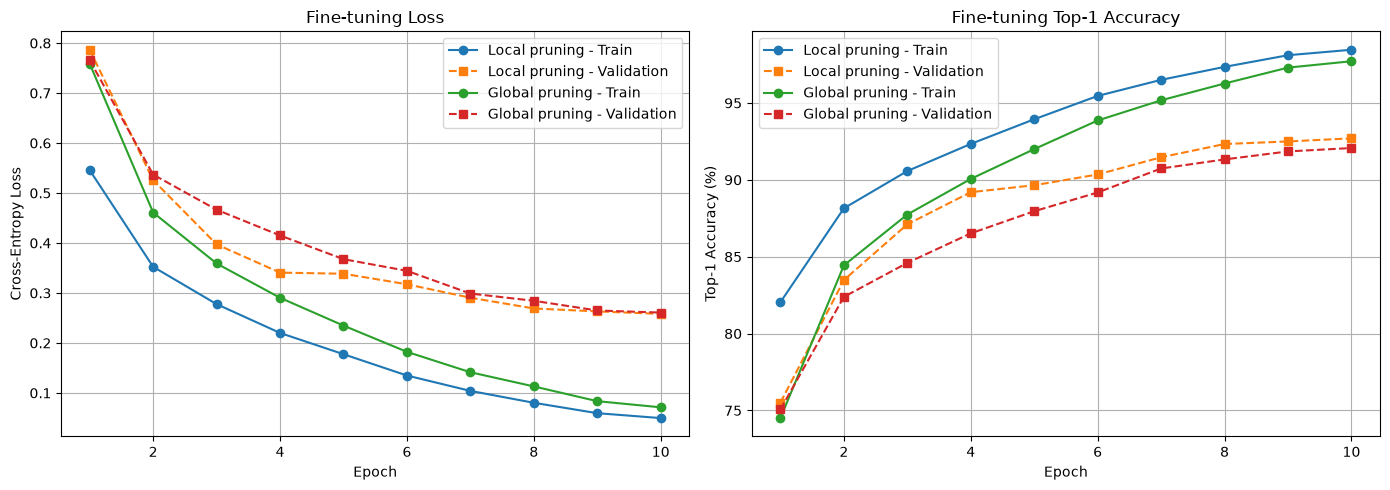

In [56]:
plot_finetuning_curves(finetuning_histories)

### Observation

| Model | Epoch 1 Val Top-1 | Final Val Top-1 | Final Train Top-1 | Final Val Loss |
|---|---:|---:|---:|---:|
| Local pruning | 75.51% | 92.70% | 98.46% | 0.2581 |
| Global pruning | 75.07% | 92.07% | 97.72% | 0.2608 |

Both models drop to about 75% after the first epoch, because a learning rate of 0.01 disturbs the pretrained weights. Accuracy then recovers steadily as the cosine schedule lowers the learning rate. Validation loss decreases every epoch with no sign of divergence. The ~6 pp gap between train and validation accuracy is similar to the dense baseline's own gap. The test set is used as the validation set.

## Part 9 — Final Comparison

### Helper Functions

In [57]:
def build_layer_sparsity_table(local_model, global_model):
    local_layers = calculate_layer_sparsity(local_model)
    global_layers = calculate_layer_sparsity(global_model)

    rows = []
    for name in local_layers:
        rows.append({
            "Layer": name,
            "Weights": local_layers[name]["total_weights"],
            "Local Sparsity (%)": local_layers[name]["sparsity"] * 100,
            "Global Sparsity (%)": global_layers[name]["sparsity"] * 100
        })
    return pd.DataFrame(rows)


def build_recovery_table():
    return pd.DataFrame([
        {"Model": "Local pruning", "Before FT Top-1 (%)": 88.85,
         "After FT Top-1 (%)": local_ft_top1},
        {"Model": "Global pruning", "Before FT Top-1 (%)": 93.11,
         "After FT Top-1 (%)": global_ft_top1},
    ]).assign(**{"Recovery (pp)": lambda df: df["After FT Top-1 (%)"] - df["Before FT Top-1 (%)"]})

### Main / Calling Functions

In [58]:
layer_sparsity_df = build_layer_sparsity_table(local_dense_masked, global_dense_masked)
recovery_df = build_recovery_table()

### Results

In [59]:
print("Layer-wise Sparsity: Local vs Global")
display(layer_sparsity_df.round(2))

print("\nAccuracy Recovery through Fine-tuning")
display(recovery_df.round(2))

print("\nFull Comparison")
display(profiling_df.round(2))

Layer-wise Sparsity: Local vs Global


,Layer,Weights,Local Sparsity (%),Global Sparsity (%)
0,conv1,1728,29.98,16.72
1,layer1.0.conv1,36864,60.00,25.98
2,layer1.0.conv2,36864,60.00,9.86
3,layer1.1.conv1,36864,60.00,10.78
4,layer1.1.conv2,36864,70.00,12.45
5,layer2.0.conv1,73728,30.00,10.53
6,layer2.0.conv2,147456,60.00,11.31
7,layer2.0.downsample.0,8192,80.00,7.18
8,layer2.1.conv1,147456,50.00,12.51
9,layer2.1.conv2,147456,70.00,16.03



Accuracy Recovery through Fine-tuning


,Model,Before FT Top-1 (%),After FT Top-1 (%),Recovery (pp)
0,Local pruning,88.85,92.70,3.85
1,Global pruning,93.11,92.07,-1.04



Full Comparison


,Model,Device,Overall Sparsity (%),Train Top-1 (%),Train Top-5 (%),Test Top-1 (%),Test Top-5 (%),Macro-F1,Dense Size (MB),Sparse Size incl. Indices (MB),MACs (M),FLOPs (M),Effective MACs (M),Latency (ms),Peak GPU Mem (MB),Avg GPU Mem (MB),CPU/GPU Energy
0,Dense full-precision baseline,mps,0.00,99.74,99.99,93.07,99.74,0.93,42.7,85.25,141.0,282.0,140.19,34.94,45.67,45.67,N/A (MPS)
1,Local magnitude pruning (dense masked),mps,78.64,98.83,99.99,92.70,99.75,0.93,42.7,18.27,141.0,282.0,43.55,34.95,46.29,46.29,N/A (MPS)
2,Global magnitude pruning (dense masked),mps,78.64,98.17,99.98,92.07,99.73,0.92,42.7,18.27,141.0,282.0,84.80,34.97,45.67,45.67,N/A (MPS)
3,Local magnitude pruning (sparse COO),mps,78.64,98.82,99.99,92.70,99.75,0.93,42.7,18.27,141.0,282.0,43.55,37.05,88.32,88.32,N/A (MPS)
4,Global magnitude pruning (sparse COO),mps,78.64,98.14,99.98,92.07,99.73,0.92,42.7,18.27,141.0,282.0,84.80,36.90,87.71,87.71,N/A (MPS)


## Discussion

### Task 1 — Discussion

**1. Which layers were the most sensitive to pruning?**
`conv1` was by far the most sensitive (93.07% → 22.15% at 90% sparsity), followed by `layer2.0.conv1` (62.78% at 90%), `layer2.1.conv1` (83.36%) and `layer2.0.conv2` (87.93%). The `layer1` convs dropped to ~88–91%. Layers in `layer3`, `layer4` and `fc` barely changed even at 90% (≥ 91%), because they hold most of the parameters and are highly redundant.

**2. Did global pruning produce a reasonable layer-wise sparsity distribution?**
Yes. With one global threshold, early layers were pruned lightly (7–29%), while `layer4` convs were pruned 88–99%, which matches the sensitivity analysis. No layer was fully pruned. `layer4.1.conv1` at 99.21% is close to collapse, and `fc` stayed at 0.12% because its weights are large in magnitude.

**3. How much accuracy was recovered through fine-tuning?**
Local pruning recovered **+3.85 pp** (88.85% → 92.70%). Global pruning was already at the baseline before fine-tuning (93.11%) and changed by **−1.04 pp** (→ 92.07%), because a learning rate of 0.01 perturbs an already well-tuned model. Both final models are within ~1 pp of the dense baseline (93.07%), well inside the 5–15 pp budget.

**4. Did COO storage reduce the actual model size?**
Not with default PyTorch COO. Each non-zero conv weight stores 4 × int64 indices (32 bytes) plus a float32 value (4 bytes), which is 36 bytes vs 4 bytes dense. At ~21% density this gives 81.86 MB vs 42.59 MB dense (−92%). COO only pays off below ~11% density (4 / 36). With flattened int32 indices (8 bytes per non-zero), storage drops to 18.20 MB, a **57.28% reduction**.

**5. Why can a model with many zero weights still have nearly the same latency as the dense model?**
Dense GPU/CPU kernels (MPS/cuDNN/BLAS) multiply every element, zeros included, so unstructured zeros save no computation. thop MACs stay at 141 M; only the effective MACs drop (43.55 M local, 84.80 M global). PyTorch has no sparse convolution kernel, so COO conv weights must be converted back to dense before every convolution, which adds overhead. Sparse matmul for `fc` has irregular memory access and index overhead that outweighs the saved multiplications at ~79% sparsity. Real speedups need structured sparsity (channels, Task 3) or hardware-supported patterns such as 2:4 semi-structured sparsity.

Measured latency: dense **34.94 ms**, dense masked **34.95 ms** (local) / **34.97 ms** (global), sparse COO **37.05 ms** (local) / **36.90 ms** (global).

# Task 2: Saliency-Based Iterative Pruning

### Task 2 — Libraries and configuration

In [64]:
import time
import copy
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from cifar10_models.resnet import resnet18

COMMON_CONFIG = {
    "seed": 42,
    "learning_rate": 0.05,
    "momentum": 0.9,
    "weight_decay": 5e-4,

    "target_sparsity": 0.7864,               # same as Task 1
    "stage_fractions": [0.50, 0.75, 1.00],   # s1, s2, s3
    "stage_targets": [20.0, 40.0, 60.0],     # prune at these accuracies (%)

    "total_epochs": 15,                      # training budget (same for both methods)
    "check_every": 20,                       # check accuracy every 20 steps (while waiting for a target)
    "log_every": len(train_loader),          # log once per epoch in the final phase

    "warmup_checkpoint": "task2_warmup_checkpoint.pt"
}

### Task 2 — Part 1: Warm-up (shared starting point for both methods, 0% → 20%)

A ResNet-18 with random weights (`resnet18(pretrained=False)`) is trained until test accuracy reaches ~20%. The warm-up is done once and saved. Both pruning methods load this same checkpoint, so they start from identical weights and optimizer state.

### Helper Functions

In [65]:
def create_random_model(seed):
    torch.manual_seed(seed)
    return resnet18(pretrained=False).to(device)     # random weights, no checkpoint


def create_optimizer(model, config):
    return torch.optim.SGD(model.parameters(), lr=config["learning_rate"],
                           momentum=config["momentum"], weight_decay=config["weight_decay"])


def new_history():
    return {"step": [], "train_loss": [], "train_top1": [], "test_loss": [], "test_top1": []}


def test_metrics(model, loader):
    """Test loss and Top-1 accuracy in one pass."""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            total_loss += criterion(outputs, targets).item() * inputs.size(0)
            correct += (outputs.argmax(dim=1) == targets).sum().item()
            total += targets.size(0)

    return total_loss / total, 100.0 * correct / total


def train_model(model, optimizer, config, history, step,
                masks=None, stop_accuracy=None, stop_step=None):
    """Generic training loop used everywhere in Task 2.
    Stops when test accuracy >= stop_accuracy, or when step reaches stop_step.
    If masks are given, pruned weights are kept at zero after every step."""
    criterion = nn.CrossEntropyLoss()
    interval = config["check_every"] if stop_accuracy is not None else config["log_every"]
    running_loss, correct, total = 0.0, 0, 0

    while True:
        for inputs, targets in train_loader:
            model.train()
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            if masks is not None:
                apply_masks(model, masks)                  # from Task 1

            step += 1
            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(dim=1) == targets).sum().item()
            total += targets.size(0)

            if step % interval == 0 or step == stop_step:
                test_loss, test_top1 = test_metrics(model, test_loader)

                history["step"].append(step)
                history["train_loss"].append(running_loss / total)
                history["train_top1"].append(100.0 * correct / total)
                history["test_loss"].append(test_loss)
                history["test_top1"].append(test_top1)
                running_loss, correct, total = 0.0, 0, 0

                print(f"Step {step} | Train Loss: {history['train_loss'][-1]:.4f} | "
                      f"Train Top-1: {history['train_top1'][-1]:.2f}% | "
                      f"Val Loss: {test_loss:.4f} | Test Top-1: {test_top1:.2f}%")

                if stop_accuracy is not None and test_top1 >= stop_accuracy:
                    return step
                if stop_step is not None and step >= stop_step:
                    return step

### Main / Calling Functions

In [66]:
warmup_model = create_random_model(COMMON_CONFIG["seed"])
torch.save(warmup_model.state_dict(), "task2_initial_weights.pt")

warmup_optimizer = create_optimizer(warmup_model, COMMON_CONFIG)
warmup_history = new_history()

start = time.perf_counter()
warmup_steps = train_model(warmup_model, warmup_optimizer, COMMON_CONFIG,
                           warmup_history, step=0,
                           stop_accuracy=COMMON_CONFIG["stage_targets"][0])
warmup_time = time.perf_counter() - start

torch.save({
    "model": warmup_model.state_dict(),
    "optimizer": warmup_optimizer.state_dict(),
    "step": warmup_steps,
    "history": warmup_history
}, COMMON_CONFIG["warmup_checkpoint"])

Step 20 | Train Loss: 2.3645 | Train Top-1: 19.61% | Val Loss: 2.1561 | Test Top-1: 25.44%


### Results

TASK 2 — WARM-UP
Warm-up steps        : 20
Warm-up time         : 4.6 s
Test Top-1 at warm-up: 25.44%
Saved: task2_initial_weights.pt, task2_warmup_checkpoint.pt


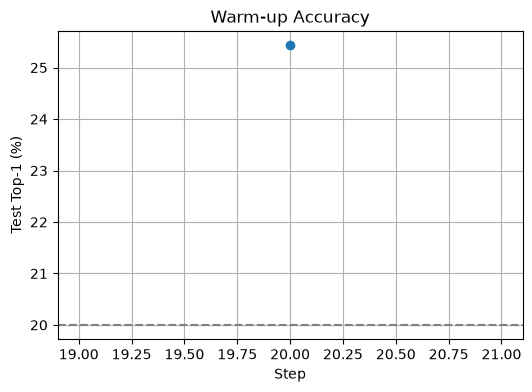

In [67]:
print("=" * 60)
print("TASK 2 — WARM-UP")
print("=" * 60)
print("Warm-up steps        :", warmup_steps)
print(f"Warm-up time         : {warmup_time:.1f} s")
print(f"Test Top-1 at warm-up: {warmup_history['test_top1'][-1]:.2f}%")
print("Saved: task2_initial_weights.pt, task2_warmup_checkpoint.pt")

plt.figure(figsize=(6, 4))
plt.plot(warmup_history["step"], warmup_history["test_top1"], marker="o")
plt.axhline(20, linestyle="--", color="gray")
plt.xlabel("Step")
plt.ylabel("Test Top-1 (%)")
plt.title("Warm-up Accuracy")
plt.grid(True)
plt.show()

### Task 2 — Part 2: Iterative Magnitude Pruning

`run_iterative_pruning(config)` is used for both methods:

1. Load the warm-up checkpoint (~20% accuracy).
2. Prune to $s_1 = 0.50\,s^\star$, train to ~40%, prune to $s_2 = 0.75\,s^\star$, train to ~60%, prune to $s_3 = s^\star$.
3. Train until the budget ends, with the mask reapplied after every step.

Pruning is **global**: all conv/linear weights are ranked together, and the weights with the highest *prune score* are removed. Bias and BatchNorm are not pruned. Weights pruned earlier get a score of $+\infty$, so they always stay pruned. This gives the cumulative mask $M_{cum,k} = M_{cum,k-1} \odot M_k$.

For magnitude pruning, prune score $= -|w|$, so the smallest weights are removed first.

### Helper Functions

In [68]:
def magnitude_prune_score(model, config):

    return {name: -module.weight.detach().abs()
            for name, module in model.named_modules()
            if isinstance(module, (nn.Conv2d, nn.Linear))}


def make_masks(scores, old_masks, sparsity):
    names = list(scores)

    all_scores = []
    for name in names:
        s = scores[name].detach().cpu().clone()
        if old_masks is not None:
            s[old_masks[name].cpu() == 0] = float("inf")
        all_scores.append(s.flatten())
    all_scores = torch.cat(all_scores)

    num_remove = int(sparsity * all_scores.numel())
    remove_idx = torch.topk(all_scores, num_remove).indices
    keep = torch.ones_like(all_scores)
    keep[remove_idx] = 0

    # Sorting check: every removed weight must score >= every kept weight
    sorting_ok = bool(all_scores[keep == 1].max() <= all_scores[remove_idx].min())

    new_masks, offset = {}, 0
    for name in names:
        n = scores[name].numel()
        stage_mask = keep[offset:offset + n].view_as(scores[name]).to(device)
        new_masks[name] = stage_mask if old_masks is None else old_masks[name] * stage_mask
        offset += n

    return new_masks, sorting_ok


def mask_sparsity(masks):
    total = sum(m.numel() for m in masks.values())
    zeros = sum((m == 0).sum().item() for m in masks.values())
    return 100.0 * zeros / total


def run_iterative_pruning(config):

    print("=" * 70)
    print(config["name"])
    print("=" * 70)

    torch.manual_seed(config["seed"])                      # same data order for both methods
    checkpoint = torch.load(config["warmup_checkpoint"], map_location=device)

    model = resnet18(pretrained=False).to(device)
    model.load_state_dict(checkpoint["model"])
    optimizer = create_optimizer(model, config)
    optimizer.load_state_dict(checkpoint["optimizer"])

    step = checkpoint["step"]
    total_steps = config["total_epochs"] * len(train_loader)
    history = new_history()
    masks = None
    stage_log = []

    for i, fraction in enumerate(config["stage_fractions"]):
        target = config["stage_targets"][i]

        # Train to the next accuracy target (stage 1 starts right after warm-up)
        if i > 0:
            step = train_model(model, optimizer, config, history, step, masks,
                               stop_accuracy=target, stop_step=total_steps)

        _, before = test_metrics(model, test_loader)

        # Pruning criterion (timed)
        start = time.perf_counter()
        scores = config["score_function"](model, config)
        synchronize(device)
        criterion_time = time.perf_counter() - start

        masks, sorting_ok = make_masks(scores, masks, fraction * config["target_sparsity"])
        apply_masks(model, masks)

        _, after = test_metrics(model, test_loader)

        stage_log.append({
            "Method": config["name"], "Stage": i + 1, "Step": step,
            "Target Accuracy (%)": target, "Reached Target": before >= target,
            "Sparsity (%)": mask_sparsity(masks),
            "Test Top-1 Before (%)": before, "Test Top-1 After (%)": after,
            "Criterion Time (s)": criterion_time, "Sorting OK": sorting_ok
        })
        print(f">> Stage {i + 1} | step {step} | sparsity {mask_sparsity(masks):.2f}% | "
              f"test {before:.2f}% -> {after:.2f}% | criterion {criterion_time:.2f}s | "
              f"sorting ok: {sorting_ok}")

    # Continue training until the budget ends
    if step < total_steps:
        step = train_model(model, optimizer, config, history, step, masks,
                           stop_step=total_steps)

    torch.save({"model": model.state_dict(), "masks": masks,
                "history": history, "stage_log": stage_log}, config["save_path"])

    return {"name": config["name"], "model": model, "masks": masks,
            "history": history, "stage_log": stage_log}


def show_run_results(result):
    print("=" * 70)
    print(result["name"])
    print("=" * 70)
    display(pd.DataFrame(result["stage_log"]).round(2))
    print(f"Final sparsity   : {mask_sparsity(result['masks']):.2f}%")
    print(f"Final Test Top-1 : {result['history']['test_top1'][-1]:.2f}%")
    print(f"Final Train Top-1: {result['history']['train_top1'][-1]:.2f}%")
    print(f"Total criterion time: {sum(r['Criterion Time (s)'] for r in result['stage_log']):.2f} s")

### Main / Calling Functions

In [69]:
MAGNITUDE_CONFIG = {
    **COMMON_CONFIG,
    "name": "Iterative Magnitude Pruning",
    "score_function": magnitude_prune_score,
    "save_path": "task2_iterative_magnitude.pt"
}

magnitude_result = run_iterative_pruning(MAGNITUDE_CONFIG)

Iterative Magnitude Pruning
>> Stage 1 | step 20 | sparsity 39.32% | test 25.44% -> 24.08% | criterion 0.01s | sorting ok: True
Step 40 | Train Loss: 1.8514 | Train Top-1: 33.46% | Val Loss: 2.1922 | Test Top-1: 30.95%
Step 60 | Train Loss: 1.6419 | Train Top-1: 38.85% | Val Loss: 1.7994 | Test Top-1: 38.44%
Step 80 | Train Loss: 1.5911 | Train Top-1: 41.74% | Val Loss: 1.5765 | Test Top-1: 42.94%
>> Stage 2 | step 80 | sparsity 58.98% | test 42.94% -> 37.45% | criterion 0.00s | sorting ok: True
Step 100 | Train Loss: 1.4585 | Train Top-1: 46.27% | Val Loss: 1.4658 | Test Top-1: 47.36%
Step 120 | Train Loss: 1.3764 | Train Top-1: 49.88% | Val Loss: 1.4146 | Test Top-1: 49.99%
Step 140 | Train Loss: 1.3859 | Train Top-1: 50.39% | Val Loss: 1.2634 | Test Top-1: 54.20%
Step 160 | Train Loss: 1.2957 | Train Top-1: 52.95% | Val Loss: 1.4194 | Test Top-1: 50.02%
Step 180 | Train Loss: 1.3201 | Train Top-1: 53.05% | Val Loss: 1.3913 | Test Top-1: 52.82%
Step 200 | Train Loss: 1.3048 | Train T

### Results

In [70]:
show_run_results(magnitude_result)

Iterative Magnitude Pruning


,Method,Stage,Step,Target Accuracy (%),Reached Target,Sparsity (%),Test Top-1 Before (%),Test Top-1 After (%),Criterion Time (s),Sorting OK
0,Iterative Magnitude Pruning,1,20,20.0,True,39.32,25.44,24.08,0.01,True
1,Iterative Magnitude Pruning,2,80,40.0,True,58.98,42.94,37.45,0.00,True
2,Iterative Magnitude Pruning,3,300,60.0,True,78.64,60.18,44.28,0.00,True


Final sparsity   : 78.64%
Final Test Top-1 : 81.84%
Final Train Top-1: 84.83%
Total criterion time: 0.01 s


### Task 2 — Part 3: Iterative GraSP Pruning

Same function and same settings as Part 2; only the score function changes.

GraSP (Algorithm 1 of the paper), computed on a small calibration set:

1. $g = \nabla_\theta L(\theta)$, averaged over the calibration batches (logits divided by temperature $T = 200$).
2. $Hg$ by double backpropagation with `torch.autograd.grad`, without building $H$: $Hg = \nabla_\theta\left(g_{\text{fixed}}^\top \nabla_\theta L(\theta)\right)$.
3. Score $S = -\theta \odot Hg$. Following the paper, the weights with the **highest** scores are removed.

### Helper Functions

In [73]:
def create_calibration_loader(num_samples, batch_size, seed):

    dataset = datasets.CIFAR10(root="./data", train=True, download=False,
                               transform=test_loader.dataset.transform)
    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=generator)[:num_samples].tolist()
    return DataLoader(Subset(dataset, indices), batch_size=batch_size, shuffle=False)

def enable_double_backward_maxpool(model):
    for name, module in model.named_children():
        if isinstance(module, nn.MaxPool2d):
            module.return_indices = True
            setattr(model, name, MaxPoolOutputOnly(module))
        else:
            enable_double_backward_maxpool(module)


class MaxPoolOutputOnly(nn.Module):
    def __init__(self, pool):
        super().__init__()
        self.pool = pool

    def forward(self, x):
        output, _ = self.pool(x)
        return output

def grasp_prune_score(model, config):

    score_model = copy.deepcopy(model).to(config["grasp_device"])
    score_model.train()
    enable_double_backward_maxpool(score_model) 

    names, weights = [], []
    for name, module in score_model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            names.append(name)
            weights.append(module.weight)

    criterion = nn.CrossEntropyLoss()
    loader = config["calibration_loader"]
    T = config["temperature"]
    num_batches = len(loader)

    # Pass 1: average gradient g
    g = [torch.zeros_like(w) for w in weights]
    for inputs, targets in loader:
        inputs, targets = inputs.to(config["grasp_device"]), targets.to(config["grasp_device"])
        loss = criterion(score_model(inputs) / T, targets)
        grads = torch.autograd.grad(loss, weights)
        for g_sum, grad in zip(g, grads):
            g_sum += grad.detach() / num_batches

    # Pass 2: Hessian-gradient product Hg (double backprop, no explicit Hessian)
    hg = [torch.zeros_like(w) for w in weights]
    for inputs, targets in loader:
        inputs, targets = inputs.to(config["grasp_device"]), targets.to(config["grasp_device"])
        loss = criterion(score_model(inputs) / T, targets)
        grads = torch.autograd.grad(loss, weights, create_graph=True)
        z = sum((g_i * grad).sum() for g_i, grad in zip(g, grads)) / num_batches
        hg_batch = torch.autograd.grad(z, weights)
        for h_sum, h in zip(hg, hg_batch):
            h_sum += h.detach()

    return {name: -(w.detach() * h).to(device) for name, w, h in zip(names, weights, hg)}

### Main / Calling Functions

In [74]:
calibration_loader = create_calibration_loader(num_samples=320, batch_size=64,
                                               seed=COMMON_CONFIG["seed"])

GRASP_CONFIG = {
    **COMMON_CONFIG,
    "name": "Iterative GraSP Pruning",
    "score_function": grasp_prune_score,
    "calibration_loader": calibration_loader,
    "temperature": 200,
    "grasp_device": device,          
    "save_path": "task2_iterative_grasp.pt"
}

grasp_result = run_iterative_pruning(GRASP_CONFIG)

Iterative GraSP Pruning
>> Stage 1 | step 20 | sparsity 39.32% | test 25.44% -> 10.25% | criterion 1.43s | sorting ok: True
Step 40 | Train Loss: 4.6729 | Train Top-1: 13.57% | Val Loss: 16.2544 | Test Top-1: 10.08%
Step 60 | Train Loss: 2.7124 | Train Top-1: 17.58% | Val Loss: 2.8945 | Test Top-1: 23.08%
Step 80 | Train Loss: 2.0854 | Train Top-1: 23.57% | Val Loss: 2.0111 | Test Top-1: 25.76%
Step 100 | Train Loss: 2.0508 | Train Top-1: 26.04% | Val Loss: 1.9234 | Test Top-1: 26.68%
Step 120 | Train Loss: 1.9298 | Train Top-1: 29.06% | Val Loss: 1.7982 | Test Top-1: 32.35%
Step 140 | Train Loss: 1.8883 | Train Top-1: 30.02% | Val Loss: 1.8724 | Test Top-1: 31.33%
Step 160 | Train Loss: 1.8639 | Train Top-1: 32.01% | Val Loss: 1.7560 | Test Top-1: 35.75%
Step 180 | Train Loss: 1.7625 | Train Top-1: 33.54% | Val Loss: 1.6784 | Test Top-1: 37.76%
Step 200 | Train Loss: 1.7113 | Train Top-1: 36.04% | Val Loss: 1.6350 | Test Top-1: 38.52%
Step 220 | Train Loss: 1.7220 | Train Top-1: 36.73

### Results

In [75]:
print("Calibration samples   :", len(calibration_loader.dataset))
print("Calibration batch size:", calibration_loader.batch_size)
print("Number of batches     :", len(calibration_loader))
print("Gradients averaged over all batches\n")

show_run_results(grasp_result)

Calibration samples   : 320
Calibration batch size: 64
Number of batches     : 5
Gradients averaged over all batches

Iterative GraSP Pruning


,Method,Stage,Step,Target Accuracy (%),Reached Target,Sparsity (%),Test Top-1 Before (%),Test Top-1 After (%),Criterion Time (s),Sorting OK
0,Iterative GraSP Pruning,1,20,20.0,True,39.32,25.44,10.25,1.43,True
1,Iterative GraSP Pruning,2,240,40.0,True,58.98,40.27,11.26,0.92,True
2,Iterative GraSP Pruning,3,1400,60.0,True,78.64,60.41,9.82,0.93,True


Final sparsity   : 78.64%
Final Test Top-1 : 70.53%
Final Train Top-1: 72.91%
Total criterion time: 3.28 s


### Accuracy and Sparsity at Every Pruning Stage

| Stage | Sparsity | Magnitude Step | Magnitude Before → After | GraSP Step | GraSP Before → After |
|---|---:|---:|---:|---:|---:|
| 1 | 39.32% | 20 | 25.44% → 24.08% | 20 | 25.44% → 10.25% |
| 2 | 58.98% | 80 | 42.94% → 37.45% | 240 | 40.27% → 11.26% |
| 3 | 78.64% | 300 | 60.18% → 44.28% | 1400 | 60.41% → 9.82% |

Warm-up stopped at 25.44% instead of exactly 20%, because accuracy is checked every 20 steps. All stage targets were reached (none were forced), and the sorting check passed at every stage.

### Observation

Magnitude pruning removes the smallest weights, so each cut reduces accuracy only slightly (1–16 pp) and the model reaches the next target quickly. GraSP drops accuracy to ~10% (chance level) after every cut, because it ranks weights by their effect on gradient flow and also removes large, already-learned weights. It therefore needs much longer to recover: GraSP reached stage 3 at step 1400, compared with step 300 for magnitude, leaving fewer steps for training at the final sparsity.

GraSP criterion time was 0.9–1.4 s per stage (3.28 s total), compared with ~0.01 s for magnitude.

### Task 2 — Part 4: Mask Check and Layer-wise Remaining-Weight Ratio

For each layer: the percentage of weights still alive, and a check that no pruned position became non-zero. A layer is treated as collapsed if less than 1% of its weights remain.

### Helper Functions

In [76]:
def layer_report(result):
    modules = dict(result["model"].named_modules())
    rows = []
    for name, mask in result["masks"].items():
        weight = modules[name].weight.data
        rows.append({
            "Layer": name,
            "Weights": mask.numel(),
            "Remaining (%)": 100.0 * mask.float().mean().item(),
            "Non-zero in Pruned": torch.count_nonzero(weight[mask == 0]).item()
        })
    return pd.DataFrame(rows)

### Main / Calling Functions

In [77]:
magnitude_layers = layer_report(magnitude_result)
grasp_layers = layer_report(grasp_result)

layer_ratio_df = pd.DataFrame({
    "Layer": magnitude_layers["Layer"],
    "Weights": magnitude_layers["Weights"],
    "Magnitude Remaining (%)": magnitude_layers["Remaining (%)"],
    "GraSP Remaining (%)": grasp_layers["Remaining (%)"]
})

collapsed_magnitude = layer_ratio_df[layer_ratio_df["Magnitude Remaining (%)"] < 1]["Layer"].tolist()
collapsed_grasp = layer_ratio_df[layer_ratio_df["GraSP Remaining (%)"] < 1]["Layer"].tolist()

### Results

In [78]:
print("Layer-wise Remaining-Weight Ratio")
display(layer_ratio_df.round(2))

for name, table in [("Magnitude", magnitude_layers), ("GraSP", grasp_layers)]:
    ok = table["Non-zero in Pruned"].sum() == 0
    print(f"{name} mask check: {'PASS - all pruned weights are zero' if ok else 'FAIL'}")

print("\nCollapsed layers (< 1% remaining)")
print("Magnitude:", collapsed_magnitude if collapsed_magnitude else "None")
print("GraSP    :", collapsed_grasp if collapsed_grasp else "None")

Layer-wise Remaining-Weight Ratio


,Layer,Weights,Magnitude Remaining (%),GraSP Remaining (%)
0,conv1,1728,68.98,11.92
1,layer1.0.conv1,36864,60.82,12.83
2,layer1.0.conv2,36864,60.46,12.81
3,layer1.1.conv1,36864,61.51,12.73
4,layer1.1.conv2,36864,60.80,12.97
5,layer2.0.conv1,73728,48.48,13.54
6,layer2.0.conv2,147456,48.21,13.75
7,layer2.0.downsample.0,8192,81.01,12.60
8,layer2.1.conv1,147456,48.00,14.02
9,layer2.1.conv2,147456,48.14,13.30


Magnitude mask check: PASS - all pruned weights are zero
GraSP mask check: PASS - all pruned weights are zero

Collapsed layers (< 1% remaining)
Magnitude: None
GraSP    : None


### Observation

Both mask checks passed: every pruned position is still zero at the end of training, so the cumulative masks worked.

The two methods distribute sparsity very differently:

- **Iterative magnitude** keeps more weights in the small early layers (`conv1` 68.98%, `layer1` ~61%, downsample layers 63–81%) and prunes the large `layer4` convs hardest (~15% remaining). This matches the sensitivity analysis from Task 1.
- **Iterative GraSP** prunes almost uniformly across the network (~12–16% remaining in `conv1`, `layer1`–`layer3`) and keeps more in `layer4` (20–25%). It keeps only 11.92% of `conv1` (~206 of 1,728 weights), the most sensitive layer in Task 1.

No layer collapsed (no layer below 1% remaining). The lowest were GraSP `conv1` (11.92%) and the magnitude `layer4` convs (15.25–15.86%).

### Task 2 — Part 5: Sparse COO Storage and Profiling

The final pruned models are converted to COO format and profiled with the same `profile_model` function as Task 1 (same batch size, device and procedure).

### Main / Calling Functions

In [79]:
task2_profiling = []

for result in [magnitude_result, grasp_result]:
    dense_model = make_dense_masked(result["model"])
    coo_model, coo_device = build_coo_model(result["model"])

    task2_profiling.append(profile_model(
        f"{result['name']} (dense masked)", dense_model, device))
    task2_profiling.append(profile_model(
        f"{result['name']} (sparse COO)", coo_model, coo_device,
        reference_model=dense_model))

task2_profiling_df = pd.DataFrame(task2_profiling)

criterion_times = {
    "Iterative Magnitude Pruning": sum(r["Criterion Time (s)"] for r in magnitude_result["stage_log"]),
    "Iterative GraSP Pruning": sum(r["Criterion Time (s)"] for r in grasp_result["stage_log"])
}
task2_profiling_df["Criterion Time (s)"] = task2_profiling_df["Model"].apply(
    lambda name: criterion_times[name.split(" (")[0]])

### Results

In [80]:
print("=" * 60)
print("TASK 2 — PROFILING")
print("=" * 60)
display(task2_profiling_df.round(2))

TASK 2 — PROFILING


,Model,Device,Overall Sparsity (%),Train Top-1 (%),Train Top-5 (%),Test Top-1 (%),Test Top-5 (%),Macro-F1,Dense Size (MB),Sparse Size incl. Indices (MB),MACs (M),FLOPs (M),Effective MACs (M),Latency (ms),Peak GPU Mem (MB),Avg GPU Mem (MB),CPU/GPU Energy,Criterion Time (s)
0,Iterative Magnitude Pruning (dense masked),mps,78.64,84.13,99.43,81.84,99.17,0.82,42.7,18.27,141.0,282.0,56.89,35.67,45.73,45.73,N/A (MPS),0.01
1,Iterative Magnitude Pruning (sparse COO),mps,78.64,83.98,99.45,81.84,99.17,0.82,42.7,18.27,141.0,282.0,56.89,37.19,90.78,90.78,N/A (MPS),0.01
2,Iterative GraSP Pruning (dense masked),mps,78.64,71.25,97.90,70.53,97.65,0.70,42.7,18.27,141.0,282.0,22.78,37.67,48.29,48.29,N/A (MPS),3.28
3,Iterative GraSP Pruning (sparse COO),mps,78.64,71.41,97.97,70.53,97.65,0.70,42.7,18.27,141.0,282.0,22.78,37.79,89.25,89.25,N/A (MPS),3.28


### Observation

| Model | Train Top-1 | Test Top-1 | Macro-F1 | Sparse Size | Effective MACs | Latency | Peak GPU Mem | Criterion Time |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Iterative Magnitude (dense masked) | 84.13% | 81.84% | 0.82 | 18.27 MB | 56.89 M | 35.67 ms | 45.73 MB | 0.01 s |
| Iterative Magnitude (sparse COO) | 83.98% | 81.84% | 0.82 | 18.27 MB | 56.89 M | 37.19 ms | 90.78 MB | 0.01 s |
| Iterative GraSP (dense masked) | 71.25% | 70.53% | 0.70 | 18.27 MB | 22.78 M | 37.67 ms | 48.29 MB | 3.28 s |
| Iterative GraSP (sparse COO) | 71.41% | 70.53% | 0.70 | 18.27 MB | 22.78 M | 37.79 ms | 89.25 MB | 3.28 s |

- **Model size:** both models have the same sparsity (78.64%), so both have the same compact COO size (18.27 MB vs 42.7 MB dense).
- **Effective MACs:** GraSP has far fewer effective MACs (22.78 M vs 56.89 M), because it pruned the early layers, which run on large 32×32 feature maps, much more heavily.
- **Latency and memory:** latency stays ~36–38 ms for all models, since dense MPS kernels still multiply the zeros. COO uses more memory (~90 MB) because of its int64 indices. This is the same behaviour as Task 1.
- **Criterion time:** GraSP needed 3.28 s in total (two gradient passes per stage), versus ~0.01 s for magnitude.
- **Energy:** not measurable through the PyTorch MPS backend (see Task 0).

### Task 2 — Part 6: Training and Validation Curves

Dashed vertical lines mark the three pruning stages.

### Helper Functions

In [81]:
def plot_task2_curves(results):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for result, color in zip(results, ["tab:blue", "tab:red"]):
        h = result["history"]
        axes[0].plot(h["step"], h["train_loss"], color=color, label=f"{result['name']} - Train")
        axes[0].plot(h["step"], h["test_loss"], color=color, linestyle="--", label=f"{result['name']} - Validation")
        axes[1].plot(h["step"], h["train_top1"], color=color, label=f"{result['name']} - Train")
        axes[1].plot(h["step"], h["test_top1"], color=color, linestyle="--", label=f"{result['name']} - Validation")

        for record in result["stage_log"]:
            for ax in axes:
                ax.axvline(record["Step"], color=color, linestyle=":", alpha=0.5)

    axes[0].set_title("Loss")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].set_ylim(0, 4)

    axes[1].set_title("Top-1 Accuracy")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Top-1 Accuracy (%)")

    for ax in axes:
        ax.grid(True)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

### Main / Calling Functions

In [82]:
task2_results = [magnitude_result, grasp_result]

### Results

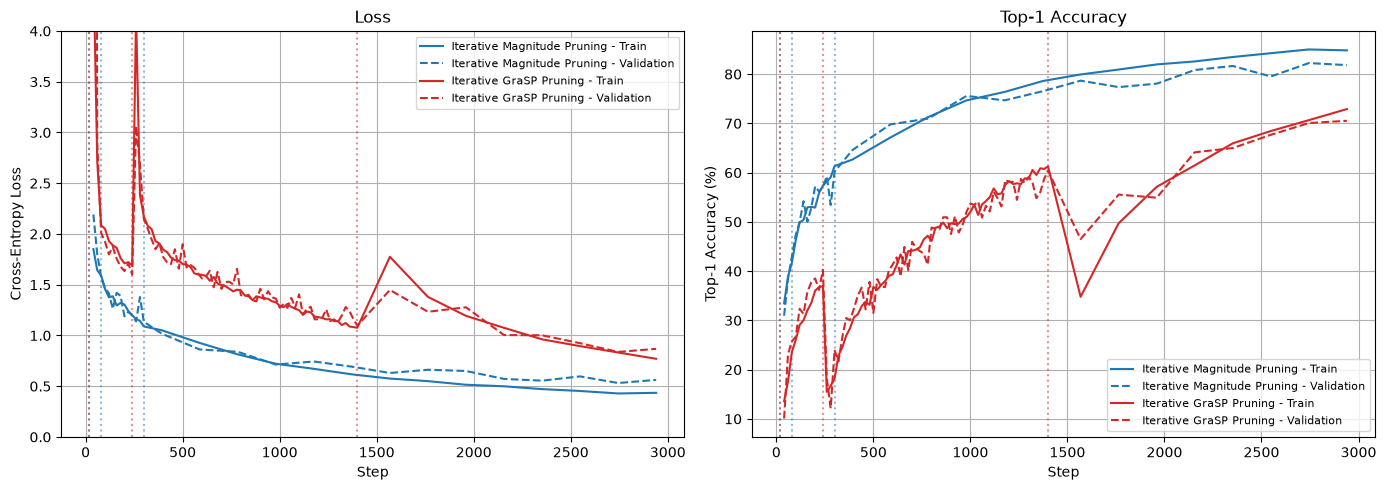

In [83]:
plot_task2_curves(task2_results)

### Observation

Each dotted line is a pruning stage. After every cut, validation accuracy drops and validation loss spikes, then both recover with further training. The drops are much larger for GraSP (to ~10% after every stage) than for magnitude (1–16 pp). GraSP needed until step 1400 to reach the third stage, versus step 300 for magnitude, so it spent less of the budget training at the final sparsity. For both methods, train and validation accuracy stay close at the end (84.13%/81.84% and 71.25%/70.53%), which shows the models are still underfitting within the 15-epoch budget rather than overfitting.

### Task 2 — Part 7: Comparison of All Pruning Methods

### Main / Calling Functions

In [84]:
comparison_columns = ["Model", "Overall Sparsity (%)", "Train Top-1 (%)", "Test Top-1 (%)",
                      "Macro-F1", "Sparse Size incl. Indices (MB)", "Effective MACs (M)",
                      "Latency (ms)", "Peak GPU Mem (MB)"]

task1_rows = profiling_df[profiling_df["Model"].str.contains("dense masked")][comparison_columns]
task2_rows = task2_profiling_df[task2_profiling_df["Model"].str.contains("dense masked")][comparison_columns]

all_methods_df = pd.concat([task1_rows, task2_rows], ignore_index=True)

### Results

In [85]:
print("Comparison: Task 1 Magnitude vs Iterative Magnitude vs Iterative GraSP")
display(all_methods_df.round(2))

Comparison: Task 1 Magnitude vs Iterative Magnitude vs Iterative GraSP


,Model,Overall Sparsity (%),Train Top-1 (%),Test Top-1 (%),Macro-F1,Sparse Size incl. Indices (MB),Effective MACs (M),Latency (ms),Peak GPU Mem (MB)
0,Local magnitude pruning (dense masked),78.64,98.83,92.70,0.93,18.27,43.55,34.95,46.29
1,Global magnitude pruning (dense masked),78.64,98.17,92.07,0.92,18.27,84.80,34.97,45.67
2,Iterative Magnitude Pruning (dense masked),78.64,84.13,81.84,0.82,18.27,56.89,35.67,45.73
3,Iterative GraSP Pruning (dense masked),78.64,71.25,70.53,0.70,18.27,22.78,37.67,48.29


### Comparison of All Pruning Methods (78.64% sparsity)

| Method | Starting Point | Train Top-1 | Test Top-1 | Macro-F1 | Effective MACs | Latency |
|---|---|---:|---:|---:|---:|---:|
| Task 1 Local Magnitude | Pretrained | 98.83% | 92.70% | 0.93 | 43.55 M | 34.95 ms |
| Task 1 Global Magnitude | Pretrained | 98.17% | 92.07% | 0.92 | 84.80 M | 34.97 ms |
| Iterative Magnitude | Random | 84.13% | 81.84% | 0.82 | 56.89 M | 35.67 ms |
| Iterative GraSP | Random | 71.25% | 70.53% | 0.70 | 22.78 M | 37.67 ms |

### Changes from the Schedule

- Warm-up stopped at **25.44%** (not exactly 20%) because accuracy is checked every 20 steps.
- Both methods used the same budget: 15 epochs, SGD (lr 0.05, constant), batch size 256.
- The test set was used as the validation set.
- For GraSP, `max_pool2d` was set to `return_indices=True` so second-order gradients could be computed.

### Task 2 — Discussion

**1. Did iterative pruning outperform magnitude-based pruning?**
No. Task 1 reached ~92%, iterative methods reached 81.84% (magnitude) and 70.53% (GraSP). Task 1 started from a fully trained model, while the iterative models trained from scratch in only 15 epochs, so they did not finish learning.

**2. Did GraSP perform better than iterative magnitude pruning?**
No. GraSP was **11.31 pp lower** (70.53% vs 81.84%). After every cut, GraSP dropped to ~10% accuracy, while magnitude lost only 1–16 pp. GraSP also removes large, useful weights, so it needed more time to recover. GraSP was designed for pruning before training, not during it. It did use fewer effective MACs (22.78 M vs 56.89 M) but took longer to compute its score (3.28 s vs 0.01 s).

**3. Did any layer collapse at high sparsity?**
No. No layer dropped below 1% of its weights. The most pruned layer was GraSP `conv1` (11.92% remaining), which is the most sensitive layer and likely lowered GraSP's accuracy.

# Task 3: Structured Pruning (Regression-Based Channel Pruning)

### Task 3 — Part 1: Configuration and Channel Plan

We prune the middle channels of every residual block (conv1 output = conv2 input). The block input/output sizes do not change, so all residual additions and shortcut projections still match. The stem conv (first convolutional block) and the fc layer are not pruned; pruning starts from `layer1`.

Pruning ratios follow the Task 1 sensitivity analysis: early layers are more sensitive, so they are pruned less; `layer4` is the least sensitive, so it is pruned most. The ratios are chosen so the overall sparsity matches Task 1 (~78.64%).

### Helper Functions

In [97]:
import torch.nn.functional as F
from sklearn.linear_model import Lasso

TASK3_CONFIG = {
    "prune_ratio": {"layer1": 0.50, "layer2": 0.60, "layer3": 0.75, "layer4": 0.83},
    "calibration_images": 128,
    "positions_per_image": 10,
    "lasso_output_channels": 128,
    "lasso_alpha_start": 0.1,  
    "lasso_max_tries": 20,
    "finetune_epochs": 5,
    "finetune_lr": 0.01,
    "seed": 42
}


def get_blocks(model):
    """All 8 residual blocks, e.g. ('layer1.0', block)."""
    blocks = []
    for stage in ["layer1", "layer2", "layer3", "layer4"]:
        for i, block in enumerate(getattr(model, stage)):
            blocks.append((f"{stage}.{i}", block))
    return blocks


def count_prunable_weights(model):
    return sum(m.weight.numel() for m in model.modules()
               if isinstance(m, (nn.Conv2d, nn.Linear)))


def plan_channels(model, config):
    """How many middle channels to keep in each block."""
    rows = []
    for name, block in get_blocks(model):
        channels = block.conv1.out_channels
        ratio = config["prune_ratio"][name.split(".")[0]]
        keep = max(1, round(channels * (1 - ratio)))

        # Weights removed per channel: one conv1 filter + one conv2 input slice
        per_channel = block.conv1.weight[0].numel() + block.conv2.weight[:, 0].numel()

        rows.append({
            "Block": name,
            "Channels": channels,
            "Keep": keep,
            "Removed": channels - keep,
            "Channel Sparsity (%)": 100 * (channels - keep) / channels,
            "Weights Removed": (channels - keep) * per_channel
        })
    return pd.DataFrame(rows)

### Main / Calling Functions

In [98]:
task3_original = load_model()
channel_plan = plan_channels(task3_original, TASK3_CONFIG)

total_weights = count_prunable_weights(task3_original)
expected_sparsity = channel_plan["Weights Removed"].sum() / total_weights

### Results

In [99]:
print("Channel plan per block")
display(channel_plan.round(2))

print(f"Total conv + linear weights : {total_weights:,}")
print(f"Weights to remove           : {channel_plan['Weights Removed'].sum():,}")
print(f"Expected overall sparsity   : {expected_sparsity * 100:.2f}%  (Task 1 target: 78.64%)")

Channel plan per block


,Block,Channels,Keep,Removed,Channel Sparsity (%),Weights Removed
0,layer1.0,64,32,32,50.00,36864
1,layer1.1,64,32,32,50.00,36864
2,layer2.0,128,51,77,60.16,133056
3,layer2.1,128,51,77,60.16,177408
4,layer3.0,256,64,192,75.00,663552
5,layer3.1,256,64,192,75.00,884736
6,layer4.0,512,87,425,83.01,2937600
7,layer4.1,512,87,425,83.01,3916800


Total conv + linear weights : 11,164,352
Weights to remove           : 8,786,880
Expected overall sparsity   : 78.70%  (Task 1 target: 78.64%)


**Instructions 4 and 5:** Removing a middle channel removes one output filter of `conv1`, its `bn1` entries, and the matching input slice of `conv2`, so both convolutions of a block are pruned by the same channel ratio. The block-output (residual) channels are not pruned, because they are shared with the shortcut path. This keeps both branches of every residual addition at the same size and channel order, so no downsample/shortcut projection needs to change.

### Main / Calling Functions

### Task 3 — Part 2: Channel Pruning, Block by Block

For every block from `layer1.0` to `layer4.1`, the same function is applied:

1. **Collect input–output pairs.** Pass calibration images through the model. $X$ is the input of `conv2`, taken from the *current pruned* model. $Y$ is the output of `conv2`, taken from the *original* model (as in He et al.). $X$ is unfolded with `F.unfold`, so $Y = X_{unf} W_{mat}$. We sample 10 positions per image.
2. **Subproblem (i): LASSO.** $Z_i = X_i W_i^\top$ for each middle channel $i$, and $\hat\beta = \arg\min_\beta \frac{1}{2N}\|Y - \sum_i \beta_i Z_i\|_F^2 + \lambda\|\beta\|_1$ (sklearn `Lasso`). If fewer than $c_0$ values are non-zero, $\lambda$ is halved and the fit is repeated. Then the $c_0$ channels with the largest $|\beta_i|$ are kept.
3. **Subproblem (ii): Least squares.** `conv2` weights are rebuilt from the kept channels with `torch.linalg.lstsq`. The $\beta_i$ scaling is absorbed into $W'$, so fitting on the unscaled kept channels gives the same solution.
4. **Remove channels.** New, smaller `conv1` (output filters), `bn1` and `conv2` (input channels) are built. The block's input/output size is unchanged, so the shortcut and residual addition still match.

### Helper Functions

In [100]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


def capture(model, module_name, images, what):

    module = dict(model.named_modules())[module_name]
    store = {}

    def hook(m, inputs, output):
        store["value"] = (inputs[0] if what == "input" else output).detach()

    handle = module.register_forward_hook(hook)
    model.eval()
    with torch.no_grad():
        model(images)
    handle.remove()
    return store["value"]


def collect_block_data(pruned_model, original_model, block_name, images, config):

    conv2 = dict(pruned_model.named_modules())[f"{block_name}.conv2"]

    X = capture(pruned_model, f"{block_name}.conv2", images, "input")      # (N, c, H, W)
    Y = capture(original_model, f"{block_name}.conv2", images, "output")   # (N, n, Ho, Wo)

    X_unf = F.unfold(X, kernel_size=conv2.kernel_size, padding=conv2.padding,
                     stride=conv2.stride).transpose(1, 2)                  # (N, L, c*k*k)
    Y_flat = Y.flatten(2).transpose(1, 2)                                   # (N, L, n)

    # Sample a few output positions per image
    N, L = X_unf.shape[0], X_unf.shape[1]
    generator = torch.Generator().manual_seed(config["seed"])
    positions = torch.randint(L, (N, config["positions_per_image"]), generator=generator).to(X.device)
    rows = torch.arange(N, device=X.device).unsqueeze(1)

    X_rows = X_unf[rows, positions].reshape(-1, X_unf.shape[2]).cpu()      # (N*P, c*k*k)
    Y_rows = Y_flat[rows, positions].reshape(-1, Y_flat.shape[2]).cpu()    # (N*P, n)
    return X_rows, Y_rows


def lasso_select_channels(X_rows, Y_rows, W, keep, config):

    n, c, kh, kw = W.shape
    R = X_rows.shape[0]

    # Z_i = X_i W_i^T for every middle channel i (on a subset of output channels for speed)
    generator = torch.Generator().manual_seed(config["seed"])
    out_idx = torch.randperm(n, generator=generator)[:min(n, config["lasso_output_channels"])]

    Z = torch.einsum("rck,nck->rnc", X_rows.view(R, c, kh * kw), W.view(n, c, kh * kw)[out_idx])
    A = Z.reshape(-1, c).numpy()                     # each column = vec(Z_i)
    y = Y_rows[:, out_idx].reshape(-1).numpy()       # vec(Y)

    # Normalize columns so the solver converges
    A = A / (np.linalg.norm(A, axis=0) + 1e-12)

    # Above lambda_max all beta are zero; start below it and lower until enough channels survive
    alpha_max = np.abs(A.T @ y).max() / len(y)
    alpha = alpha_max * config["lasso_alpha_start"]

    for _ in range(config["lasso_max_tries"]):
        lasso = Lasso(alpha=alpha, fit_intercept=False, precompute=True, max_iter=5000)
        lasso.fit(A, y)
        beta = torch.tensor(lasso.coef_)
        if (beta != 0).sum() >= keep:
            break
        alpha /= 2

    keep_idx = torch.topk(beta.abs(), keep).indices.sort().values
    return keep_idx, beta, alpha

def least_squares_weights(X_rows, Y_rows, keep_idx, W):

    n, c, kh, kw = W.shape
    R = X_rows.shape[0]

    X_kept = X_rows.view(R, c, kh * kw)[:, keep_idx, :].reshape(R, -1)   # (R, c0*k*k)
    solution = torch.linalg.lstsq(X_kept, Y_rows).solution               # (c0*k*k, n)
    return solution.T.reshape(n, len(keep_idx), kh, kw)


def shrink_block(block, keep_idx, new_conv2_weight):

    old_conv1, old_bn1, old_conv2 = block.conv1, block.bn1, block.conv2
    dev = old_conv1.weight.device
    keep_idx = keep_idx.to(dev)
    c0 = len(keep_idx)

    conv1 = nn.Conv2d(old_conv1.in_channels, c0, old_conv1.kernel_size,
                      old_conv1.stride, old_conv1.padding, bias=False)
    conv1.weight.data = old_conv1.weight.data[keep_idx].clone()

    bn1 = nn.BatchNorm2d(c0)
    bn1.weight.data = old_bn1.weight.data[keep_idx].clone()
    bn1.bias.data = old_bn1.bias.data[keep_idx].clone()
    bn1.running_mean = old_bn1.running_mean[keep_idx].clone()
    bn1.running_var = old_bn1.running_var[keep_idx].clone()

    conv2 = nn.Conv2d(c0, old_conv2.out_channels, old_conv2.kernel_size,
                      old_conv2.stride, old_conv2.padding, bias=False)
    conv2.weight.data = new_conv2_weight.to(dev)

    block.conv1, block.bn1, block.conv2 = conv1.to(dev), bn1.to(dev), conv2.to(dev)


def prune_block(pruned_model, original_model, block_name, block, keep, images, config):

    start = time.perf_counter()
    channels = block.conv1.out_channels

    X_rows, Y_rows = collect_block_data(pruned_model, original_model, block_name, images, config)
    W = block.conv2.weight.detach().cpu()

    keep_idx, beta, alpha = lasso_select_channels(X_rows, Y_rows, W, keep, config)
    new_weight = least_squares_weights(X_rows, Y_rows, keep_idx, W)
    shrink_block(block, keep_idx, new_weight)

    _, test_top1 = test_metrics(pruned_model, test_loader)

    return {
        "Block": block_name,
        "Channels Before": channels,
        "Channels After": keep,
        "Non-zero Beta": int((beta != 0).sum()),
        "Lambda Used": f"{alpha:.2e}",
        "Test Top-1 After (%)": test_top1,
        "Time (s)": time.perf_counter() - start
    }


def structured_sparsity(original_model, pruned_model):
    return 1 - count_prunable_weights(pruned_model) / count_prunable_weights(original_model)

### Main / Calling Functions

In [101]:
# Calibration images (training set, no augmentation) - from Task 2
task3_calibration_loader = create_calibration_loader(
    num_samples=TASK3_CONFIG["calibration_images"],
    batch_size=TASK3_CONFIG["calibration_images"],
    seed=TASK3_CONFIG["seed"]
)
calibration_images = next(iter(task3_calibration_loader))[0].to(device)

# Prune all 8 blocks with the same function
task3_pruned = copy.deepcopy(task3_original)
block_records = []

for (block_name, block), keep in zip(get_blocks(task3_pruned), channel_plan["Keep"]):
    record = prune_block(task3_pruned, task3_original, block_name, block, keep,
                         calibration_images, TASK3_CONFIG)
    block_records.append(record)
    print(f"{block_name}: {record['Channels Before']} -> {record['Channels After']} channels | "
          f"Test Top-1: {record['Test Top-1 After (%)']:.2f}% | {record['Time (s)']:.1f}s")

block_results = pd.DataFrame(block_records)
task3_sparsity = structured_sparsity(task3_original, task3_pruned)
_, task3_before_ft = test_metrics(task3_pruned, test_loader)

layer1.0: 64 -> 32 channels | Test Top-1: 92.48% | 2.2s
layer1.1: 64 -> 32 channels | Test Top-1: 91.52% | 2.0s
layer2.0: 128 -> 51 channels | Test Top-1: 88.98% | 2.0s
layer2.1: 128 -> 51 channels | Test Top-1: 83.52% | 1.9s
layer3.0: 256 -> 64 channels | Test Top-1: 78.17% | 2.0s
layer3.1: 256 -> 64 channels | Test Top-1: 78.57% | 1.9s
layer4.0: 512 -> 87 channels | Test Top-1: 77.64% | 2.0s
layer4.1: 512 -> 87 channels | Test Top-1: 77.77% | 1.9s


### Results

In [102]:
print("=" * 60)
print("TASK 3 — CHANNEL PRUNING (before fine-tuning)")
print("=" * 60)
print(f"Calibration images     : {TASK3_CONFIG['calibration_images']}")
print(f"Positions per image    : {TASK3_CONFIG['positions_per_image']}")
print(f"Rows per regression    : {TASK3_CONFIG['calibration_images'] * TASK3_CONFIG['positions_per_image']}")
display(block_results.round(4))

print(f"Weights before : {count_prunable_weights(task3_original):,}")
print(f"Weights after  : {count_prunable_weights(task3_pruned):,}")
print(f"Structured sparsity     : {task3_sparsity * 100:.2f}%")
print(f"Test Top-1 before FT    : {task3_before_ft:.2f}%")

TASK 3 — CHANNEL PRUNING (before fine-tuning)
Calibration images     : 128
Positions per image    : 10
Rows per regression    : 1280


,Block,Channels Before,Channels After,Non-zero Beta,Lambda Used,Test Top-1 After (%),Time (s)
0,layer1.0,64,32,64,1.29e-06,92.48,2.1817
1,layer1.1,64,32,64,6.11e-07,91.52,1.9691
2,layer2.0,128,51,128,7.90e-07,88.98,2.0306
3,layer2.1,128,51,127,4.47e-07,83.52,1.9314
4,layer3.0,256,64,255,2.51e-07,78.17,2.0186
5,layer3.1,256,64,145,5.23e-07,78.57,1.9083
6,layer4.0,512,87,101,3.30e-07,77.64,1.9696
7,layer4.1,512,87,93,2.15e-07,77.77,1.9223


Weights before : 11,164,352
Weights after  : 2,377,472
Structured sparsity     : 78.70%
Test Top-1 before FT    : 77.77%


### Observation

Pruning was applied block by block from `layer1.0` to `layer4.1`. For every block, LASSO returned at least as many non-zero β values as channels to keep, and the $c_0$ channels with the largest $|\beta|$ were kept. Accuracy decreases gradually as more blocks are pruned, from 93.07% to **77.77%** after all 8 blocks, without any fine-tuning. The model now has 2,377,472 conv/linear weights instead of 11,164,352 (**78.70% structured sparsity**), matching the Task 1 target (78.64%).

LASSO columns were normalized before fitting, and λ was set relative to $\lambda_{max}$ and halved until enough channels had non-zero β. Each block took ~2 s.

### Task 3 — Part 3: Fine-tuning

After all blocks are pruned, the smaller model is fine-tuned with cross-entropy loss, using the same fine-tuning function as Task 1. No masks are needed, because the removed channels no longer exist.

### Main / Calling Functions

In [103]:
torch.manual_seed(TASK3_CONFIG["seed"])

task3_ft_model, task3_history = fine_tune_model(
    task3_pruned,
    train_loader,
    test_loader,
    TASK3_CONFIG["finetune_epochs"],
    TASK3_CONFIG["finetune_lr"],
    device
)

Epoch 1/5 | Loss: 1.0243 | Train Top-1: 64.14% | Test Top-1: 68.15% Val Loss: 0.9349 | 
Epoch 2/5 | Loss: 0.6629 | Train Top-1: 77.06% | Test Top-1: 71.84% Val Loss: 0.8736 | 
Epoch 3/5 | Loss: 0.5107 | Train Top-1: 82.63% | Test Top-1: 78.62% Val Loss: 0.6297 | 
Epoch 4/5 | Loss: 0.4015 | Train Top-1: 86.35% | Test Top-1: 85.15% Val Loss: 0.4441 | 
Epoch 5/5 | Loss: 0.3199 | Train Top-1: 89.30% | Test Top-1: 87.89% Val Loss: 0.3549 | 


### Results

TASK 3 — FINE-TUNING
Test Top-1 before pruning : 93.07%
Test Top-1 after pruning  : 77.77%
Test Top-1 after FT       : 87.89%
Recovery                  : +10.12 pp


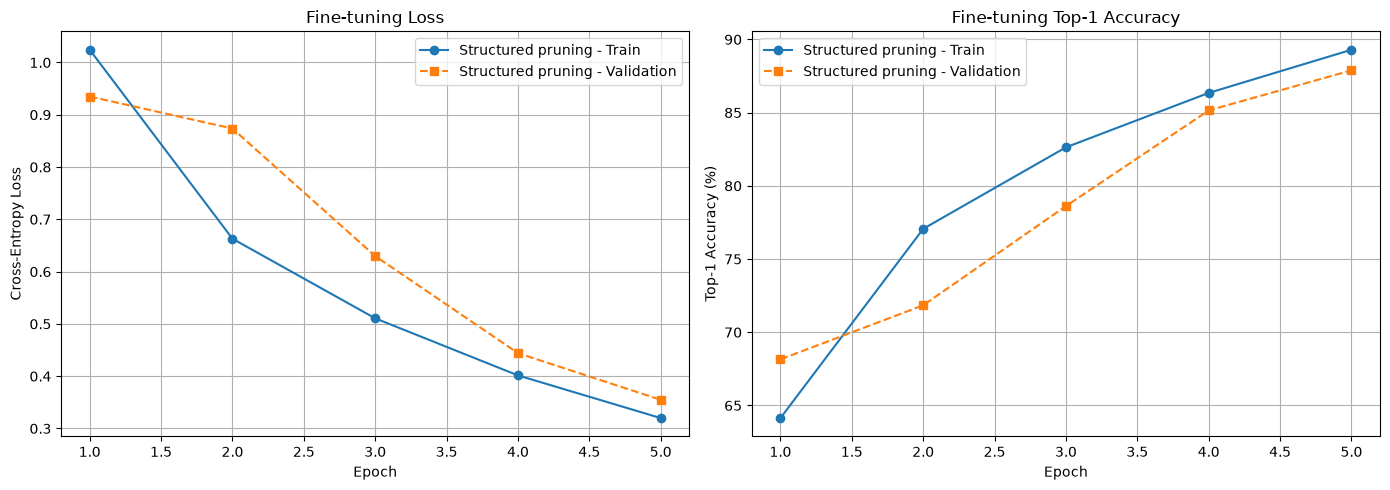

In [105]:
_, task3_after_ft = test_metrics(task3_ft_model, test_loader)

print("=" * 60)
print("TASK 3 — FINE-TUNING")
print("=" * 60)
print(f"Test Top-1 before pruning : 93.07%")
print(f"Test Top-1 after pruning  : {task3_before_ft:.2f}%")
print(f"Test Top-1 after FT       : {task3_after_ft:.2f}%")
print(f"Recovery                  : {task3_after_ft - task3_before_ft:+.2f} pp")

plot_finetuning_curves({"Structured pruning": task3_history})

### Task 3 — Part 4: Profiling and Comparison

The pruned model is profiled with the same `profile_model` function as Tasks 1 and 2. No sparse format is needed, because the remaining filters are dense and the layers are physically smaller. Sparsity is reported as structured sparsity: the fraction of conv/linear weights removed.

### Main / Calling Functions

In [106]:
task3_row = profile_model("Structured channel pruning (Task 3)", task3_ft_model, device)
task3_row["Overall Sparsity (%)"] = task3_sparsity * 100

comparison_columns = ["Model", "Overall Sparsity (%)", "Train Top-1 (%)", "Test Top-1 (%)",
                      "Macro-F1", "Dense Size (MB)", "MACs (M)", "FLOPs (M)", "Latency (ms)",
                      "Peak GPU Mem (MB)", "Avg GPU Mem (MB)"]

final_comparison = pd.concat([
    profiling_df[comparison_columns].iloc[[0, 1, 2]],                 # dense, Task 1 local, Task 1 global
    task2_profiling_df[comparison_columns].iloc[[0, 2]],              # Task 2 magnitude, GraSP
    pd.DataFrame([task3_row])[comparison_columns]                     # Task 3
], ignore_index=True)

### Results

In [107]:
print("=" * 60)
print("FINAL COMPARISON — ALL TASKS")
print("=" * 60)
display(final_comparison.round(2))

FINAL COMPARISON — ALL TASKS


,Model,Overall Sparsity (%),Train Top-1 (%),Test Top-1 (%),Macro-F1,Dense Size (MB),MACs (M),FLOPs (M),Latency (ms),Peak GPU Mem (MB),Avg GPU Mem (MB)
0,Dense full-precision baseline,0.00,99.74,93.07,0.93,42.70,141.00,282.00,34.94,45.67,45.67
1,Local magnitude pruning (dense masked),78.64,98.83,92.70,0.93,42.70,141.00,282.00,34.95,46.29,46.29
2,Global magnitude pruning (dense masked),78.64,98.17,92.07,0.92,42.70,141.00,282.00,34.97,45.67,45.67
3,Iterative Magnitude Pruning (dense masked),78.64,84.13,81.84,0.82,42.70,141.00,282.00,35.67,45.73,45.73
4,Iterative GraSP Pruning (dense masked),78.64,71.25,70.53,0.70,42.70,141.00,282.00,37.67,48.29,48.29
5,Structured channel pruning (Task 3),78.70,90.53,87.89,0.88,9.16,49.92,99.85,20.52,24.05,24.05


### Task 3 — Results

| Model | Sparsity | Test Top-1 | Macro-F1 | Size (MB) | MACs (M) | Latency (ms) | Peak GPU Mem (MB) |
|---|---:|---:|---:|---:|---:|---:|---:|
| Dense baseline | 0.00% | 93.07% | 0.93 | 42.70 | 141.00 | 34.94 | 45.67 |
| Task 1 Local Magnitude | 78.64% | 92.70% | 0.93 | 42.70 | 141.00 | 34.95 | 46.29 |
| Task 1 Global Magnitude | 78.64% | 92.07% | 0.92 | 42.70 | 141.00 | 34.97 | 45.67 |
| Task 2 Iterative Magnitude | 78.64% | 81.84% | 0.82 | 42.70 | 141.00 | 35.67 | 45.73 |
| Task 2 Iterative GraSP | 78.64% | 70.53% | 0.70 | 42.70 | 141.00 | 37.67 | 48.29 |
| **Task 3 Structured Channel** | **78.70%** | **87.89%** | **0.88** | **9.16** | **49.92** | **20.52** | **24.05** |

**Accuracy:** 93.07% → 77.77% after pruning → **87.89%** after 5 epochs of fine-tuning (lr 0.01).

**Improvement over the dense baseline:**

| Metric | Baseline | Task 3 | Change |
|---|---:|---:|---:|
| Model size | 42.70 MB | 9.16 MB | −78.5% |
| MACs | 141.00 M | 49.92 M | −64.6% |
| Latency | 34.94 ms | 20.52 ms | −41.3% (1.7× faster) |
| Peak GPU memory | 45.67 MB | 24.05 MB | −47.3% |

Energy: not measurable through the PyTorch MPS backend (see Task 0).

### Did you see an improvement in performance (memory, latency) while meeting the accuracy constraint? Why or why not?

**Yes.** Test accuracy dropped by only **5.18 pp** (93.07% → 87.89%), which is within the 5–15 pp constraint. Latency dropped by **41%** and GPU memory by **47%**.

**Why it works:** unstructured pruning (Tasks 1 and 2) only sets weights to zero. The tensors keep their full size, so the GPU still multiplies the zeros and nothing gets faster. Structured pruning **removes whole channels**, so the conv layers become physically smaller dense tensors. There are fewer weights to store, fewer MACs to compute, and smaller feature maps in memory, and no special sparse library is needed.

**Why latency did not drop as much as the weights (78.7%):**
- MACs dropped only 64.6%, because the early layers, which run on large 32×32 feature maps, were pruned less (50%), while `layer4`, pruned most (83%), runs on tiny 4×4 maps.
- The stem, the shortcut/downsample convs, BatchNorm, ReLU and the residual additions are not pruned and still take time.
- Small layers don't use the GPU fully, and kernel-launch overhead stays the same.